**Установка баблиотек**

In [42]:
!pip install xgboost
!pip install catboost
!pip install lime shap

**Импорт библиотек**

In [43]:
import pandas as pd
import numpy as np
from pandas.tseries.holiday import USFederalHolidayCalendar

import lime
import lime.lime_tabular
import shap

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.model_selection import TunedThresholdClassifierCV
import sklearn
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    accuracy_score, roc_auc_score, average_precision_score,
    auc, precision_score, recall_score, f1_score, make_scorer
)

from scipy.stats import chi2_contingency

import kagglehub

**Загрузка данных**

In [44]:
path = kagglehub.dataset_download("kartik2112/fraud-detection")

print("Путь к файлу:", path)

Using Colab cache for faster access to the 'fraud-detection' dataset.
Путь к файлу: /kaggle/input/fraud-detection


In [45]:
df_train = pd.read_csv(f"{path}/fraudTrain.csv", index_col=0)
df_test = pd.read_csv(f"{path}/fraudTest.csv", index_col=0)


# **EDA**

In [46]:
print(f"Размер train: {df_train.shape}")
print(f"Размер test: {df_test.shape}")

Размер train: (1296675, 22)
Размер test: (555719, 22)


**Описание колонок (с типами данных)**

| Признак | Тип данных | Описание |
|---|---|---|
| trans_date_trans_time | object | Временная метка транзакции |
| cc_num | int64 | Номер кредитной карты клиента |
| merchant | object | Название продавца |
| category | object | Категория транзакции |
| amt | float64 | Сумма транзакции |
| first | object | Имя держателя карты |
| last | object | Фамилия держателя карты |
| gender | object | Пол держателя карты |
| street | object | Улица (адрес) клиента |
| city | object | Город клиента |
| state | object | Штат клиента |
| zip | int64 | Почтовый индекс клиента |
| lat | float64 | Широта клиента |
| long | float64 | Долгота клиента |
| city_pop | int64 | Население города клиента |
| job | object | Профессия клиента |
| dob | object | Дата рождения клиента |
| trans_num | object | Уникальный идентификатор транзакции |
| unix_time | int64 | Время транзакции в формате Unix |
| merch_lat | float64 | Широта продавца |
| merch_long | float64 | Долгота продавца |
| is_fraud | int64 | Целевая переменная (фрод/не фрод) |

**Обработка временных и географических данных**

In [47]:
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['dob'] = pd.to_datetime(df_train['dob'])
df_train['age'] = df_train['trans_date_trans_time'].dt.year - df_train['dob'].dt.year

In [48]:
df_train['hour'] = df_train['trans_date_trans_time'].dt.hour
df_train['day'] = df_train['trans_date_trans_time'].dt.day
df_train['month'] = df_train['trans_date_trans_time'].dt.month
df_train['day_of_week'] = df_train['trans_date_trans_time'].dt.dayofweek

In [49]:
# Дистанция между продавцом и покуаптелем

def calculate_distance(df):
    lat1, lon1 = np.radians(df['lat']), np.radians(df['long'])
    lat2, lon2 = np.radians(df['merch_lat']), np.radians(df['merch_long'])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

df_train['distance_km'] = calculate_distance(df_train)

**Статистики**

In [50]:
df_train.describe().T

,count,mean,min,25%,50%,75%,max,std
trans_date_trans_time,1296675,2019-10-03 12:47:28.070214144,2019-01-01 00:00:18,2019-06-03 19:12:22.500000,2019-10-03 07:35:47,2020-01-28 15:02:55.500000,2020-06-21 12:13:37,NaN
cc_num,1296675.0,417192042079726656.0,60416207185.0,180042946491150.0,3521417320836166.0,4642255475285942.0,4992346398065154048.0,1308806447000789248.0
amt,1296675.0,70.351035,1.0,9.65,47.52,83.14,28948.9,160.316039
zip,1296675.0,48800.671097,1257.0,26237.0,48174.0,72042.0,99783.0,26893.222476
lat,1296675.0,38.537622,20.0271,34.6205,39.3543,41.9404,66.6933,5.075808
long,1296675.0,-90.226335,-165.6723,-96.798,-87.4769,-80.158,-67.9503,13.759077
city_pop,1296675.0,88824.440563,23.0,743.0,2456.0,20328.0,2906700.0,301956.360689
dob,1296675,1973-10-03 19:02:55.017178512,1924-10-30 00:00:00,1962-08-13 00:00:00,1975-11-30 00:00:00,1987-02-22 00:00:00,2005-01-29 00:00:00,NaN
unix_time,1296675.0,1349243636.726123,1325376018.0,1338750742.5,1349249747.0,1359385375.5,1371816817.0,12841278.42336
merch_lat,1296675.0,38.537338,19.027785,34.733572,39.36568,41.957164,67.510267,5.109788


In [51]:
df_train.nunique()

,0
trans_date_trans_time,1274791
cc_num,983
merchant,693
category,14
amt,52928
first,352
last,481
gender,2
street,983
city,894


**Графики**

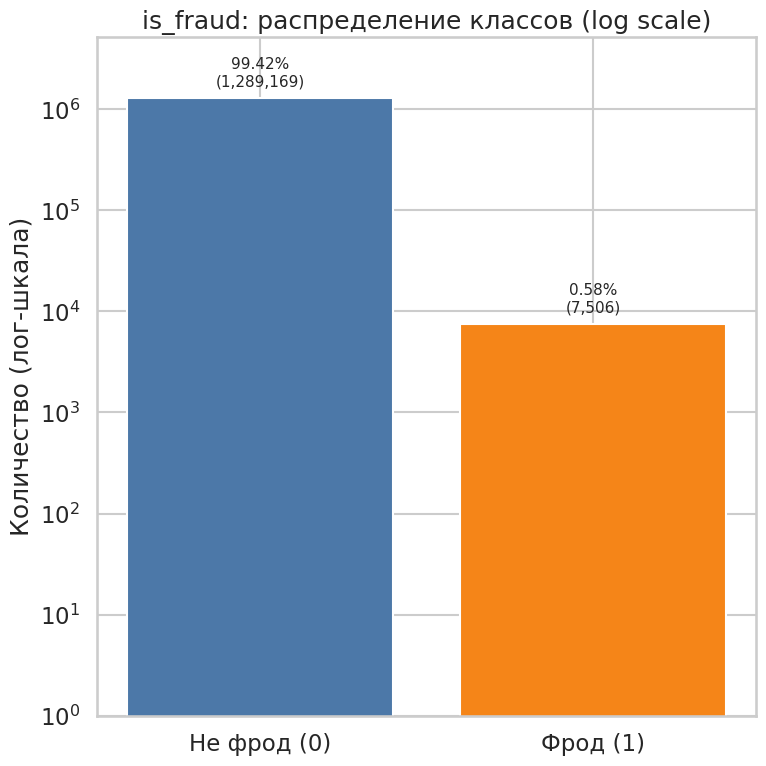

In [52]:
sns.set_theme(style="whitegrid", context="talk")

counts = df_train["is_fraud"].value_counts().reindex([0, 1], fill_value=0)
perc = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 8))

x = ["Не фрод (0)", "Фрод (1)"]
bars = ax.bar(x, counts.values, color=["#4C78A8", "#F58518"])

ax.set_yscale("log")
ax.set_ylabel("Количество (лог-шкала)")
ax.set_title("is_fraud: распределение классов (log scale)")

# --- добавляем место сверху, чтобы подписи не упирались ---
ymax = counts.max()
ax.set_ylim(1, ymax * 4)   # можно 1.5 / 2 / 3 — подбери как нравится

for bar, p, c in zip(bars, perc.values, counts.values):
    ax.annotate(f"{p:.2f}%\n({c:,})",
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom",
                textcoords="offset points", xytext=(0, 6),
                fontsize=11, clip_on=False)

plt.tight_layout()
plt.show()

В `df_train` наблюдается выраженный дисбаланс классов: подавляющее большинство операций - легитимные (класс 0) - **1 289 169 транзакций (99.42%)**, тогда как мошеннических операций (класс 1) всего **7 506 (0.58%)**. Из-за такого перекоса accuracy будет малоинформативной, поэтому при моделировании стоит ориентироваться на метрики для редкого класса (например, PR-AUC/Recall/F1) и учитывать при обучении дисбаланс.

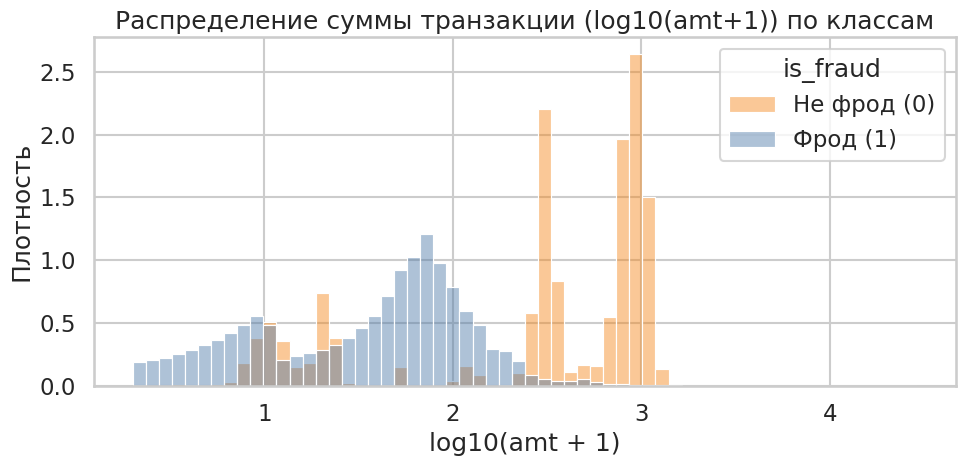

In [53]:
# 2) Распределение сумм транзакций: fraud vs non-fraud (лог-преобразование)

sns.set_theme(style="whitegrid", context="talk")

tmp = df_train[["amt", "is_fraud"]].copy()
tmp["log10_amt"] = np.log10(tmp["amt"] + 1)  # log(amt+1), чтобы не было проблем с малыми значениями

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=tmp,
    x="log10_amt",
    hue="is_fraud",
    bins=60,
    stat="density",
    common_norm=False,
    alpha=0.45,
    palette={0: "#4C78A8", 1: "#F58518"},
    ax=ax
)

ax.set_title("Распределение суммы транзакции (log10(amt+1)) по классам")
ax.set_xlabel("log10(amt + 1)")
ax.set_ylabel("Плотность")
ax.legend(title="is_fraud", labels=["Не фрод (0)", "Фрод (1)"])

plt.tight_layout()
plt.show()

/tmp/ipykernel_6553/2833499270.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


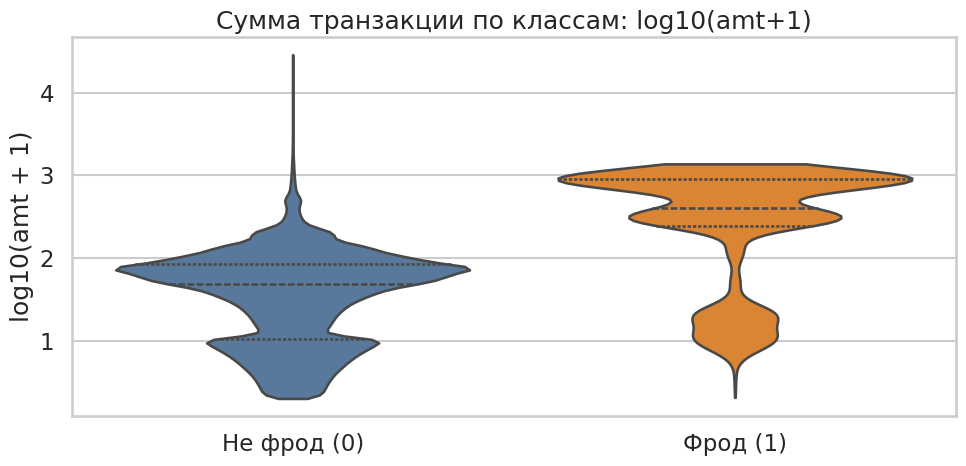

In [54]:
# 3) Сравнение распределений сумм: violin/box по log10(amt+1)
sns.set_theme(style="whitegrid", context="talk")

tmp = df_train[["amt", "is_fraud"]].copy()
tmp["log10_amt"] = np.log10(tmp["amt"] + 1)
tmp["class"] = tmp["is_fraud"].map({0: "Не фрод (0)", 1: "Фрод (1)"})

fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(
    data=tmp, x="class", y="log10_amt",
    inner="quartile", cut=0,
    palette=["#4C78A8", "#F58518"],
    ax=ax
)

ax.set_title("Сумма транзакции по классам: log10(amt+1)")
ax.set_xlabel("")
ax.set_ylabel("log10(amt + 1)")

plt.tight_layout()
plt.show()

По гистограмме видно, что сумма транзакции заметно различается между классами. У легитимных операций (0) распределение смещено в сторону более крупных сумм и имеет выраженные пики примерно в районе log10(amt+1) ≈ 2.8–3.0 (это порядка 600–1000 по amt), что похоже на “типовые” суммы. У мошеннических операций (1) распределение в среднем левее - основной массив лежит примерно в районе log10(amt+1) ≈ 1.7–2.1 (то есть около 50–125), при этом есть заметный “хвост” к совсем малым суммам. Перекрытие распределений присутствует, но сдвиг достаточно явный - значит, amt (лучше в лог-преобразовании) потенциально полезный признак для модели.


По violin-графику видно, что распределения сумм у классов заметно различаются: у фрода (1) значения log10(amt+1) в среднем выше (медиана и межквартильный размах смещены вверх), с выраженной плотностью в зоне примерно 2.5–3.0 (то есть суммы порядка сотен–тысяч), тогда как у не фрода (0) основная масса наблюдений сосредоточена ниже, около 1.6–2.0 (десятки–сотня). При этом у обоих классов видна мультимодальность (несколько “горбов”), что может отражать типовые размеры платежей. Перекрытие есть, но сдвиг достаточно сильный

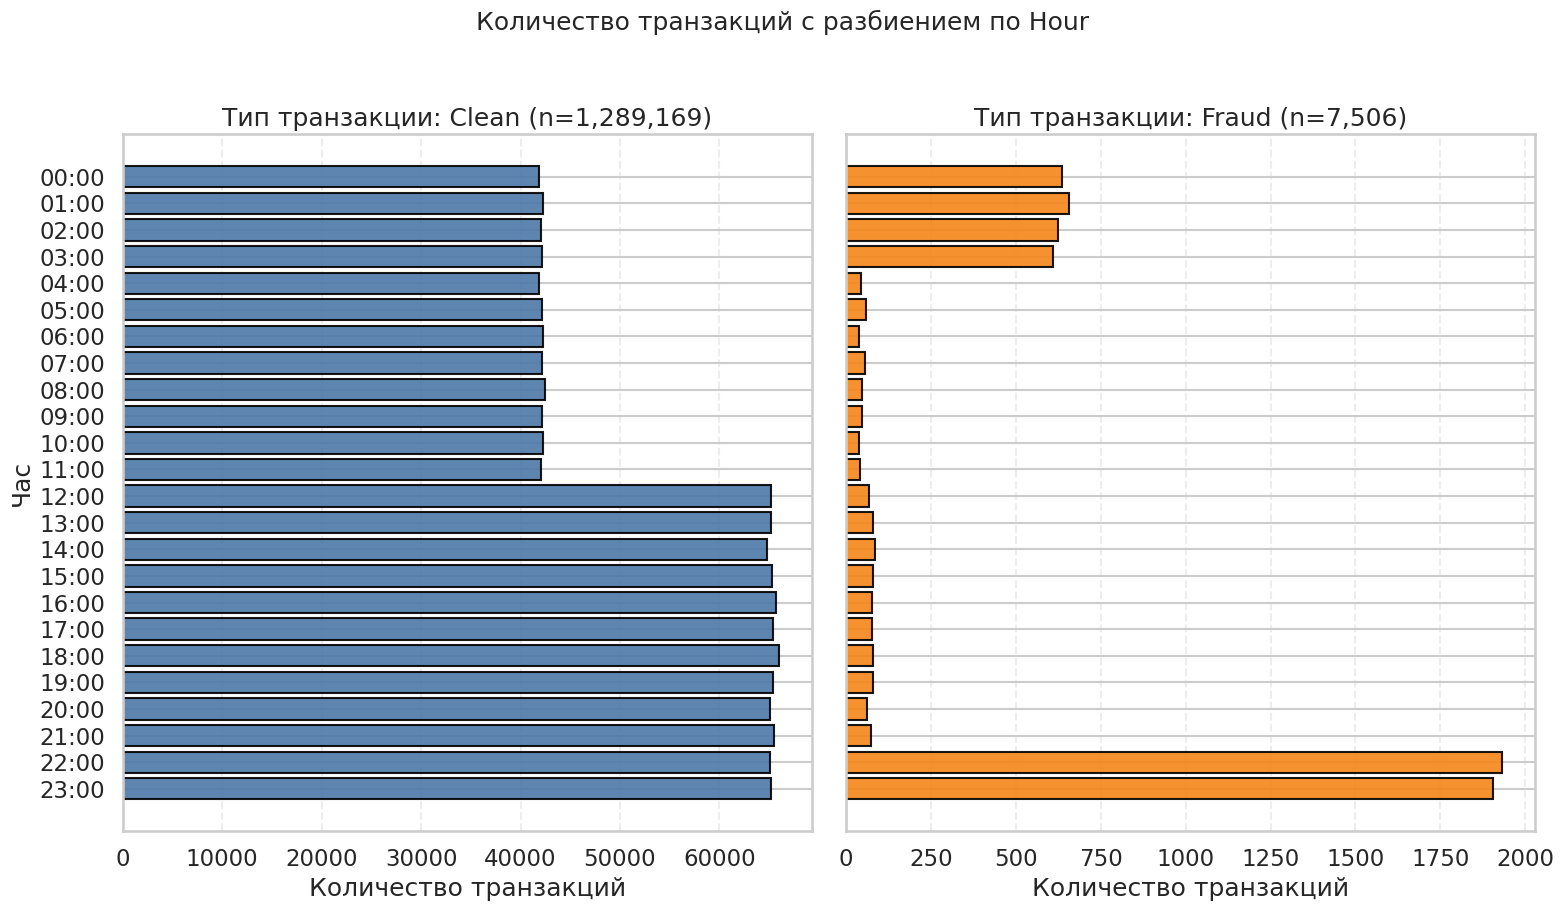

In [55]:
# Количество транзакций по часам: отдельно Clean и Fraud (как на примере)

sns.set_theme(style="whitegrid", context="talk")

HOURS = pd.Index(range(24), name="hour")

clean = (df_train.loc[df_train["is_fraud"] == 0, "hour"]
         .value_counts().reindex(HOURS, fill_value=0).sort_index())
fraud = (df_train.loc[df_train["is_fraud"] == 1, "hour"]
         .value_counts().reindex(HOURS, fill_value=0).sort_index())

# понятные подписи часов: 00:00 ... 23:00 (и при этом часы пронумерованы 0..23)
hour_labels = [f"{h:02d}:00" for h in HOURS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9), sharey=True)

# наши цвета (как раньше)
c_clean = "#4C78A8"  # синий
c_fraud = "#F58518"  # оранжевый

# Clean
ax1.barh(HOURS, clean.values, color=c_clean, edgecolor="black", alpha=0.9)
ax1.set_title(f"Тип транзакции: Clean (n={clean.sum():,})")
ax1.set_xlabel("Количество транзакций")
ax1.set_ylabel("Час")
ax1.set_yticks(HOURS)
ax1.set_yticklabels([f"{lbl}" for lbl in hour_labels])
ax1.grid(True, axis="x", linestyle="--", alpha=0.35)

# Fraud
ax2.barh(HOURS, fraud.values, color=c_fraud, edgecolor="black", alpha=0.9)
ax2.set_title(f"Тип транзакции: Fraud (n={fraud.sum():,})")
ax2.set_xlabel("Количество транзакций")
ax2.set_ylabel("")
ax2.set_yticks(HOURS)
ax2.set_yticklabels([f"{lbl}" for lbl in hour_labels])
ax2.grid(True, axis="x", linestyle="--", alpha=0.35)

# чтобы 0-й час был сверху (как на примере)
ax1.invert_yaxis()

fig.suptitle("Количество транзакций с разбиением по Hour", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

На графике видно, что распределение **количества** транзакций по часам сильно отличается для чистых и мошеннических операций. Для **Clean** поток относительно ровный в ночные/утренние часы и заметно возрастает днём и вечером (примерно с 12:00 до 23:00) - это похоже на обычное поведение пользователей, когда активность выше во второй половине дня. Для **Fraud** картина иная: основные всплески приходятся на поздний вечер, особенно на **22:00–23:00**, тогда как в большинстве остальных часов число фрод-транзакций значительно ниже. С учётом того, что в датасете в целом доля фрода очень мала, такой «концентрационный» паттерн по часу выглядит полезным - признак `hour` потенциально информативен.

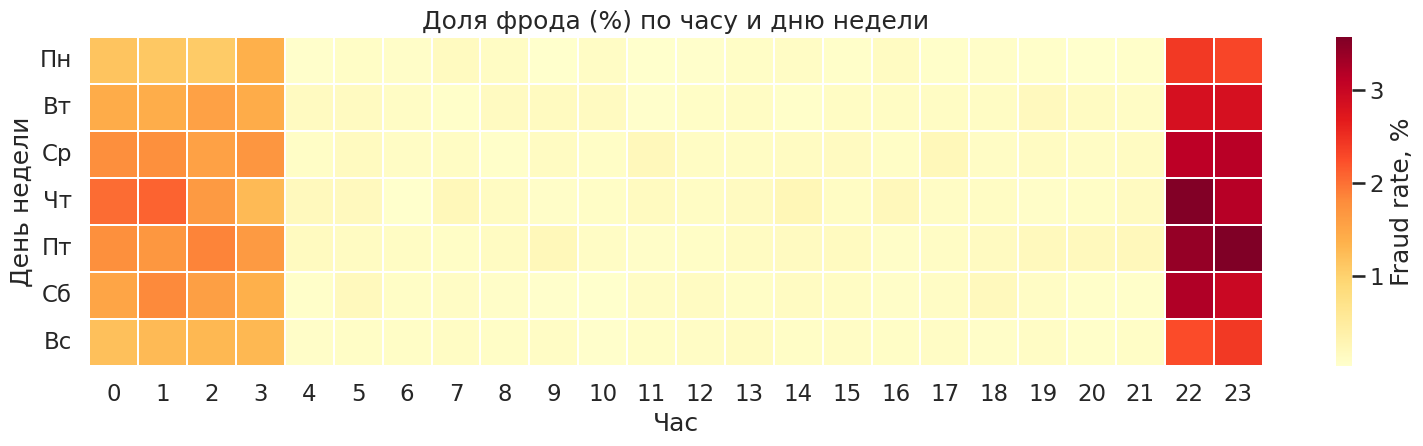

In [56]:
# Fraud rate heatmap: час (0–23) × день недели (0–6)

dow_names = {0: "Пн", 1: "Вт", 2: "Ср", 3: "Чт", 4: "Пт", 5: "Сб", 6: "Вс"}

pivot = (df_train
         .pivot_table(values="is_fraud", index="day_of_week", columns="hour", aggfunc="mean")
         .reindex(index=range(7), columns=range(24))
         * 100)

fig, ax = plt.subplots(figsize=(16, 4.8))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Fraud rate, %"},
    ax=ax
)

ax.set_title("Доля фрода (%) по часу и дню недели")
ax.set_xlabel("Час")
ax.set_ylabel("День недели")
ax.set_yticklabels([dow_names[i] for i in pivot.index], rotation=0)

plt.tight_layout()
plt.show()

Паттерн стабильный по дням недели: основная вариативность идёт именно от часа, а не от дня

/tmp/ipykernel_6553/2557417058.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


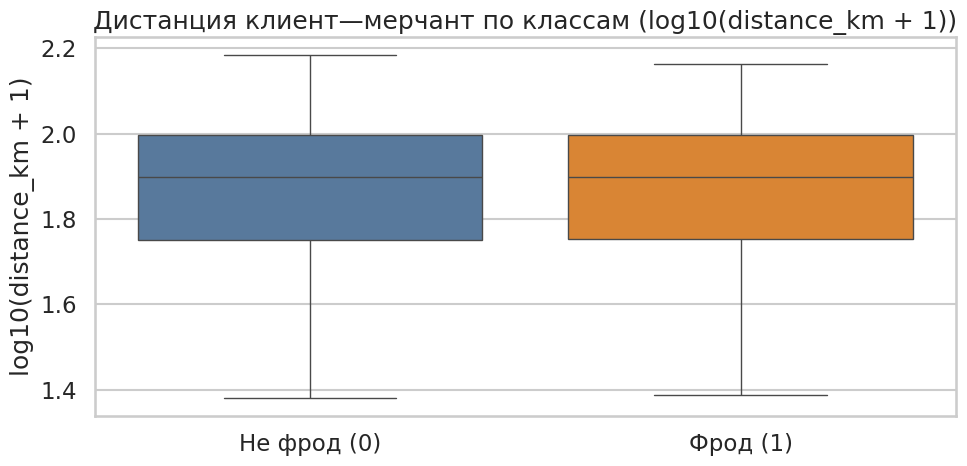

In [57]:
# Сравнение distance_km по классам (лог-преобразование, чтобы лучше читались хвосты)

sns.set_theme(style="whitegrid", context="talk")

tmp = df_train[["distance_km", "is_fraud"]].copy()
tmp["log10_dist"] = np.log10(tmp["distance_km"] + 1)
tmp["class"] = tmp["is_fraud"].map({0: "Не фрод (0)", 1: "Фрод (1)"})

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=tmp, x="class", y="log10_dist",
    order=["Не фрод (0)", "Фрод (1)"],
    palette={"Не фрод (0)": "#4C78A8", "Фрод (1)": "#F58518"},
    showfliers=False,
    ax=ax
)

ax.set_title("Дистанция клиент—мерчант по классам (log10(distance_km + 1))")
ax.set_xlabel("")
ax.set_ylabel("log10(distance_km + 1)")

plt.tight_layout()
plt.show()

По boxplot видно, что распределения distance_km у фрода и не фрода почти совпадают: медианы находятся примерно на одном уровне, межквартильные размахи очень похожи, а «усы» (диапазон без выбросов) отличаются минимально. Это означает, что в текущем виде признак дистанции слабо разделяет классы и сам по себе, вероятно, даст небольшой вклад в качество модели.

/tmp/ipykernel_6553/712788316.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = (tmp.groupby("age_bin")["is_fraud"]
/tmp/ipykernel_6553/712788316.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


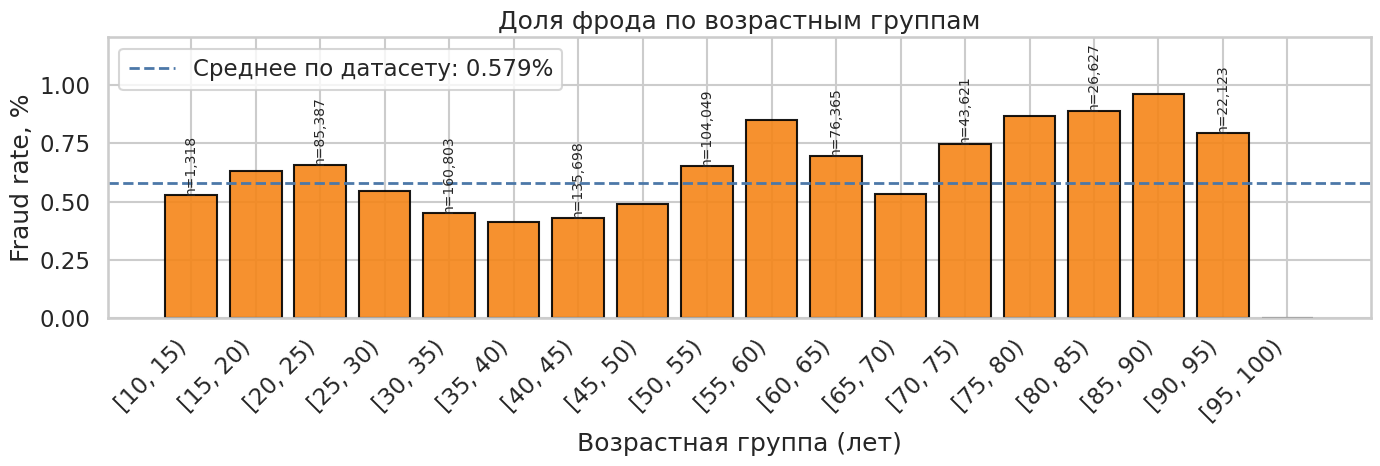

In [58]:
# Fraud rate (%) по возрастным группам (age bins)

sns.set_theme(style="whitegrid", context="talk")

# биннинг возраста (5 лет)
bins = np.arange(10, 101, 5)  # 10–100
tmp = df_train[["age", "is_fraud"]].copy()
tmp["age_bin"] = pd.cut(tmp["age"], bins=bins, right=False)

g = (tmp.groupby("age_bin")["is_fraud"]
     .agg(rate="mean", n="size")
     .reset_index())

g["rate_pct"] = g["rate"] * 100
overall = df_train["is_fraud"].mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(g["age_bin"].astype(str), g["rate_pct"], color="#F58518", edgecolor="black", alpha=0.9)
ax.axhline(overall, color="#4C78A8", linestyle="--", linewidth=2, label=f"Среднее по датасету: {overall:.3f}%")

ax.set_title("Доля фрода по возрастным группам")
ax.set_xlabel("Возрастная группа (лет)")
ax.set_ylabel("Fraud rate, %")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# немного воздуха сверху
ax.set_ylim(0, max(0.2, float(g["rate_pct"].max() * 1.25)))

# подписи количества наблюдений (через одну группу, чтобы не перегружать)
for i, (x, y, n) in enumerate(zip(g["age_bin"].astype(str), g["rate_pct"], g["n"])):
    if i % 2 == 0:
        ax.text(i, y, f"n={n:,}", ha="center", va="bottom", fontsize=10, rotation=90)

ax.legend()
plt.tight_layout()
plt.show()

График показывает, что доля фрода зависит от возраста не монотонно, но есть заметные зоны повышенного риска. Относительно среднего по датасету (~0.579%)
 ниже среднего выглядят группы примерно 30–50 лет (столбцы около 0.4–0.55%), тогда как после 55–60 лет fraud rate чаще выше среднего и в старших возрастах (примерно 75–95) достигает максимальных значений на графике (порядка ~0.8–1.0%). При этом важно учитывать подписи n: для крайних возрастных интервалов выборка меньше, поэтому оценки там могут быть более шумными; тренд “рост риска в пожилых группах” всё равно выглядит устойчивым и делает age потенциально полезным признаком

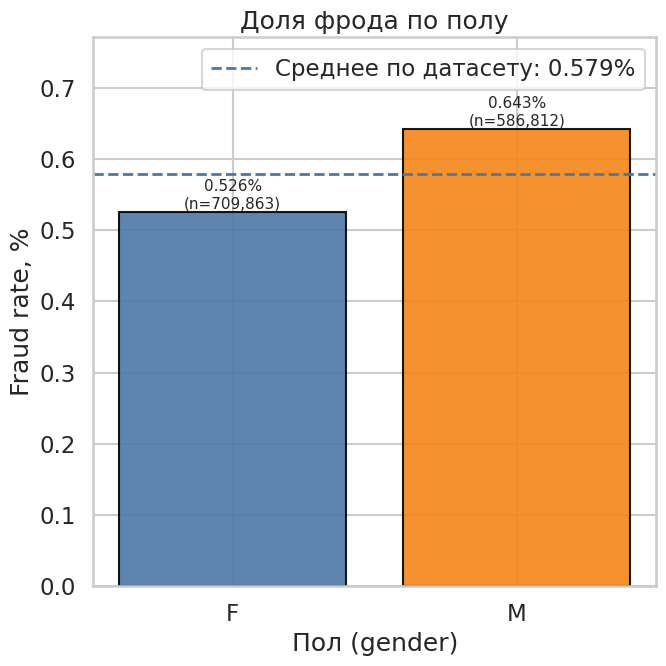

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

g = (df_train.groupby("gender")["is_fraud"]
     .agg(rate="mean", n="size")
     .reset_index())
g["rate_pct"] = g["rate"] * 100

overall = df_train["is_fraud"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 7))

colors = ["#4C78A8", "#F58518"]  # наши цвета
bars = ax.bar(g["gender"], g["rate_pct"], color=colors, edgecolor="black", alpha=0.9)

ax.axhline(overall, color="#4C78A8", linestyle="--", linewidth=2,
           label=f"Среднее по датасету: {overall:.3f}%")

ax.set_title("Доля фрода по полу")
ax.set_xlabel("Пол (gender)")
ax.set_ylabel("Fraud rate, %")

# чуть воздуха сверху
ax.set_ylim(0, max(0.2, float(g["rate_pct"].max() * 1.2)))

for bar, p, n in zip(bars, g["rate_pct"], g["n"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{p:.3f}%\n(n={n:,})",
            ha="center", va="bottom", fontsize=11)

ax.legend()
plt.tight_layout()
plt.show()

In [60]:
ct = pd.crosstab(df_train["gender"], df_train["is_fraud"])
print("Contingency table (counts):\n", ct, "\n")

chi2, p, dof, expected = chi2_contingency(ct)

n = ct.to_numpy().sum()
r, c = ct.shape
cramers_v = np.sqrt(chi2 / (n * (min(r-1, c-1))))

rates = (ct[1] / ct.sum(axis=1) * 100).rename("fraud_rate_%")
print(rates, "\n")

print(f"Chi2={chi2:.4f}, dof={dof}, p-value={p:.6g}")
print(f"Cramér's V={cramers_v:.6f}  (0≈нет связи, 1≈сильная связь)")

Contingency table (counts):
 is_fraud       0     1
gender                
F         706128  3735
M         583041  3771 

gender
F    0.526158
M    0.642625
Name: fraud_rate_%, dtype: float64 

Chi2=75.5146, dof=1, p-value=3.62721e-18
Cramér's V=0.007631  (0≈нет связи, 1≈сильная связь)


По полу наблюдается различие: у мужчин fraud rate выше (0.643%) чем у женщин (0.526%), но разница небольшая в абсолютных пунктах (≈0.117 п.п.). Хи‑квадрат тест дал p-value = 3.63e-18, то есть статистически зависимость “пол ↔ фрод” обнаруживается; однако Cramér’s V = 0.0076 - это крайне маленький размер эффекта (практически связь очень слабая). Такое сочетание (супер‑малый p при маленьком V) типично при больших выборках: у нас в train порядка 1.3 млн транзакций и сам фрод редкий (среднее is_fraud ≈ 0.005789), поэтому тест легко “видит” даже микроскопические отличия.

Вывод для модели: gender может дать небольшой прирост как слабый признак, но сам по себе не является сильным разделителем; полезнее рассматривать его во взаимодействиях (например, с возрастом, временем, категориями/мерчантами) и оценивать вклад по feature importance/SHAP и по метрикам на валидации.

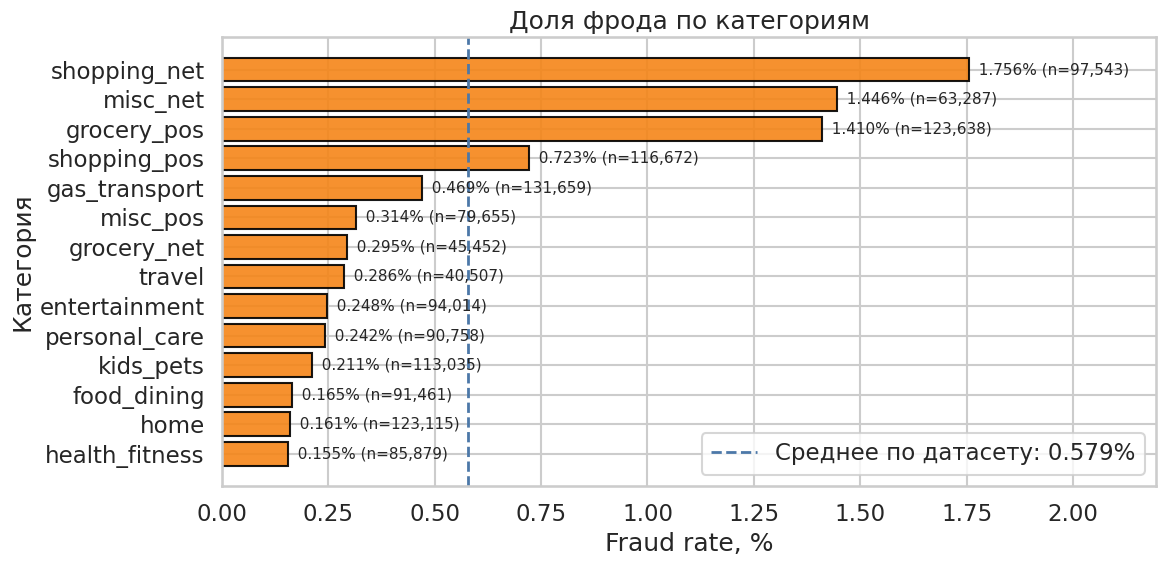

In [61]:
# Доля фрода по категориям (category): fraud rate (%) + размер группы n

sns.set_theme(style="whitegrid", context="talk")

g = (df_train.groupby("category")["is_fraud"]
     .agg(rate="mean", n="size")
     .reset_index())
g["rate_pct"] = g["rate"] * 100
g = g.sort_values("rate_pct", ascending=True)  # для barh

overall = df_train["is_fraud"].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(g["category"], g["rate_pct"], color="#F58518", edgecolor="black", alpha=0.9)

ax.axvline(overall, color="#4C78A8", linestyle="--", linewidth=2,
           label=f"Среднее по датасету: {overall:.3f}%")

ax.set_title("Доля фрода по категориям")
ax.set_xlabel("Fraud rate, %")
ax.set_ylabel("Категория")

# немного воздуха справа
ax.set_xlim(0, max(0.2, float(g["rate_pct"].max() * 1.25)))

# подписи: fraud rate и n
for bar, p, n in zip(bars, g["rate_pct"], g["n"]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f"  {p:.3f}% (n={n:,})",
            va="center", ha="left", fontsize=11)

ax.legend()
plt.tight_layout()
plt.show()

График показывает, что риск фрода сильно зависит от **категории** и разброс по fraud rate заметно выше среднего по датасету (**0.579%**) [1]. Лидеры по доле фрода - **shopping_net (1.756%)**, **misc_net (1.446%)** и **grocery_pos (1.410%)**: это примерно в **2.4–3 раза выше** среднего уровня, причём значения выглядят устойчивыми, потому что размеры групп большие (десятки/сотни тысяч транзакций). Категория **shopping_pos (0.723%)** тоже выше среднего, но уже умеренно. Большинство остальных категорий (например, `grocery_net`, `travel`, `entertainment`, `health_fitness`) находятся **существенно ниже среднего** (≈0.15–0.32%), то есть дают более “безопасный” фон. Вывод: `category` - один из самых информативных категориальных признаков.

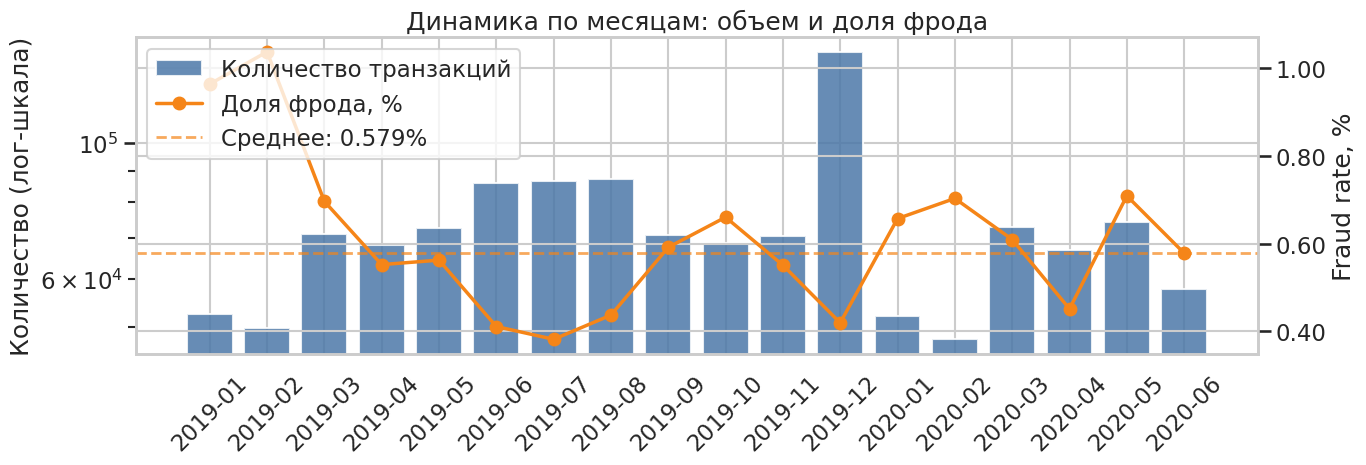

In [62]:
# Динамика по месяцам: количество транзакций (log) + доля фрода (%)

sns.set_theme(style="whitegrid", context="talk")

tmp = df_train[["trans_date_trans_time", "is_fraud"]].copy()
tmp["year_month"] = tmp["trans_date_trans_time"].dt.to_period("M").astype(str)

g = (tmp.groupby("year_month")["is_fraud"]
     .agg(n="size", rate="mean")
     .reset_index())

overall = df_train["is_fraud"].mean() * 100  # средняя доля фрода по датасету [1]
g["rate_pct"] = g["rate"] * 100

fig, ax1 = plt.subplots(figsize=(14, 5))

# bars: объем транзакций
ax1.bar(g["year_month"], g["n"], color="#4C78A8", alpha=0.85, label="Количество транзакций")
ax1.set_yscale("log")
ax1.set_ylabel("Количество (лог-шкала)")
ax1.tick_params(axis="x", rotation=45)

# line: fraud rate
ax2 = ax1.twinx()
ax2.plot(g["year_month"], g["rate_pct"], color="#F58518", marker="o", linewidth=2.5, label="Доля фрода, %")
ax2.axhline(overall, color="#F58518", linestyle="--", linewidth=2, alpha=0.7,
            label=f"Среднее: {overall:.3f}%")
ax2.set_ylabel("Fraud rate, %")
ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))

ax1.set_title("Динамика по месяцам: объем и доля фрода")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

График показывает сезонность сразу по двум осям. По объёму транзакций (синие столбцы, лог‑шкала) заметны колебания по месяцам и выраженный пик в **2019‑12** - в декабре транзакций существенно больше, чем в соседние месяцы (типично для праздничного сезона). Доля фрода (оранжевая линия) при этом не фиксирована: она колеблется вокруг среднего по датасету **0.579%** [1], с более высокими значениями в начале периода (например, **2019‑01/2019‑02**) и отдельными локальными всплесками в **2020‑02** и **2020‑05**, а минимумы видны летом **2019‑06–2019‑08**. Важно, что высокий объём операций не всегда означает высокий fraud rate (например, декабрьский пик по количеству не сопровождается максимальной долей фрода), поэтому для моделирования полезно учитывать временные признаки (месяц/сезонность) и аккуратно валидировать по времени (time-based split), чтобы не переоценить качество на “похожих” месяцах.

In [63]:
from scipy.stats import norm

tmp = df_train[["trans_date_trans_time", "is_fraud"]].copy()
tmp["ym"] = tmp["trans_date_trans_time"].dt.to_period("M").astype(str)

m = tmp.groupby("ym")["is_fraud"].agg(n="size", frauds="sum", rate="mean").reset_index()
m["rate_%"] = 100*m["rate"]
display(m)

# 2-proportion z-test: Jan-Feb 2019 vs Mar 2019+
cut = pd.Timestamp("2019-03-01")
a = tmp.loc[tmp["trans_date_trans_time"] < cut, "is_fraud"]
b = tmp.loc[tmp["trans_date_trans_time"] >= cut, "is_fraud"]

x1, n1 = int(a.sum()), int(a.shape[0])
x2, n2 = int(b.sum()), int(b.shape[0])

p1, p2 = x1/n1, x2/n2
p_pool = (x1 + x2) / (n1 + n2)
se = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
z = (p1 - p2) / se
p_value = 2*(1 - norm.cdf(abs(z)))

print(f"До 2019-03: {100*p1:.3f}% (n={n1:,}, frauds={x1:,})")
print(f"С  2019-03: {100*p2:.3f}% (n={n2:,}, frauds={x2:,})")
print(f"z={z:.3f}, p-value={p_value:.3g}")

,ym,n,frauds,rate,rate_%
0,2019-01,52525,506,0.009634,0.963351
1,2019-02,49866,517,0.010368,1.036779
2,2019-03,70939,494,0.006964,0.696373
3,2019-04,68078,376,0.005523,0.552308
4,2019-05,72532,408,0.005625,0.562510
5,2019-06,86064,354,0.004113,0.411322
6,2019-07,86596,331,0.003822,0.382235
7,2019-08,87359,382,0.004373,0.437276
8,2019-09,70652,418,0.005916,0.591632
9,2019-10,68758,454,0.006603,0.660287


До 2019-03: 0.999% (n=102,391, frauds=1,023)
С  2019-03: 0.543% (n=1,194,284, frauds=6,483)
z=18.470, p-value=0


По агрегатам по месяцам видно явное «до/после»: в январе–феврале 2019 fraud rate держится около 1% (2019‑01: 0.963%, 2019‑02: 1.037%) при сопоставимом объёме транзакций (~50k в месяц), а начиная с марта 2019 доля фрода заметно ниже и в среднем стабилизируется около 0.54% (с колебаниями по месяцам), что согласуется с общей средней долей фрода в train 0.579%. Разница между периодами подтверждается тестом разницы долей: до 2019‑03 - 0.999% (n=102,391) против с 2019‑03 - 0.543% (n=1,194,284), z=18.47, p-value практически нулевой, то есть это не случайный шум, а статистически очень устойчивый сдвиг. Такая картина похожа на смену режима (policy/concept drift): либо действительно изменились антифрод‑правила/процессы разметки, либо существенно поменялся состав транзакций (категории, часы, география) после 2019‑03

period
post(>=2019-03)    1194284
pre(<2019-03)       102391
Name: count, dtype: int64


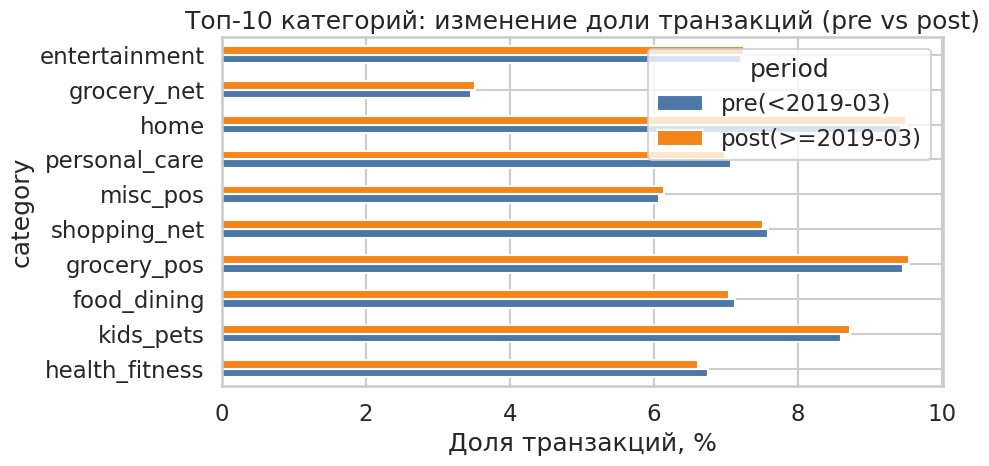

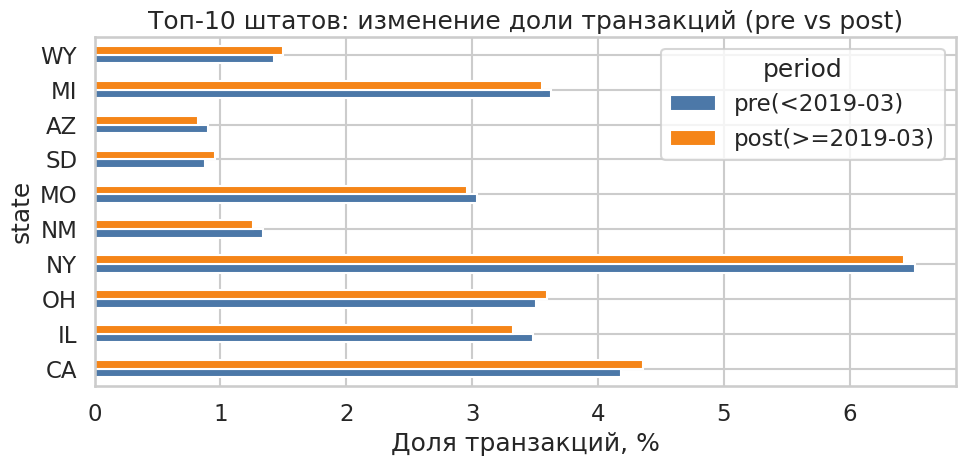

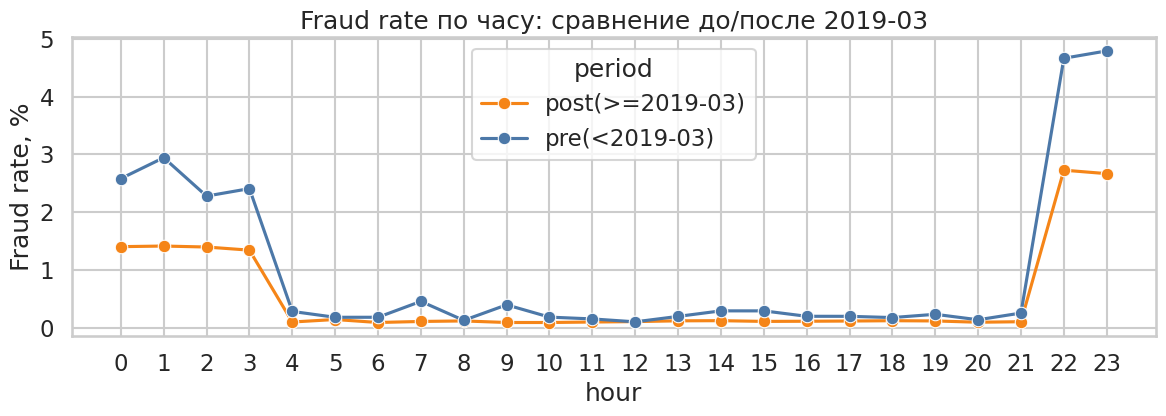

In [64]:
sns.set_theme(style="whitegrid", context="talk")

cut = pd.Timestamp("2019-03-01")
tmp = df_train[["trans_date_trans_time", "is_fraud", "category", "hour", "state"]].copy()
tmp["period"] = np.where(tmp["trans_date_trans_time"] < cut, "pre(<2019-03)", "post(>=2019-03)")

print(tmp["period"].value_counts())

# --- 1) Сдвиг микса категорий (доля транзакций) ---
cat_share = (pd.crosstab(tmp["category"], tmp["period"], normalize="columns") * 100)
cat_share["diff_post-pre_pp"] = cat_share["post(>=2019-03)"] - cat_share["pre(<2019-03)"]
cat_top = cat_share.reindex(cat_share["diff_post-pre_pp"].abs().sort_values(ascending=False).head(10).index)

fig, ax = plt.subplots(figsize=(10, 5))
cat_top[["pre(<2019-03)", "post(>=2019-03)"]].plot(kind="barh", ax=ax, color=["#4C78A8", "#F58518"])
ax.set_title("Топ-10 категорий: изменение доли транзакций (pre vs post)")
ax.set_xlabel("Доля транзакций, %")
ax.set_ylabel("category")
plt.tight_layout()
plt.show()

# --- 2) Сдвиг микса штатов (доля транзакций) ---
state_share = (pd.crosstab(tmp["state"], tmp["period"], normalize="columns") * 100)
state_share["diff_post-pre_pp"] = state_share["post(>=2019-03)"] - state_share["pre(<2019-03)"]
state_top = state_share.reindex(state_share["diff_post-pre_pp"].abs().sort_values(ascending=False).head(10).index)

fig, ax = plt.subplots(figsize=(10, 5))
state_top[["pre(<2019-03)", "post(>=2019-03)"]].plot(kind="barh", ax=ax, color=["#4C78A8", "#F58518"])
ax.set_title("Топ-10 штатов: изменение доли транзакций (pre vs post)")
ax.set_xlabel("Доля транзакций, %")
ax.set_ylabel("state")
plt.tight_layout()
plt.show()

# --- 3) Fraud rate по часу: pre vs post ---
hr = (tmp.groupby(["period", "hour"])["is_fraud"].mean().reset_index())
hr["rate_pct"] = hr["is_fraud"] * 100

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.lineplot(data=hr, x="hour", y="rate_pct", hue="period", marker="o",
             palette={"pre(<2019-03)": "#4C78A8", "post(>=2019-03)": "#F58518"}, ax=ax)
ax.set_title("Fraud rate по часу: сравнение до/после 2019-03")
ax.set_xlabel("hour")
ax.set_ylabel("Fraud rate, %")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

Падение fraud rate с ~1% до ~0.54% плохо объясняется изменением состава транзакций.

In [65]:
cut = pd.Timestamp("2019-03-01")
tmp = df_train[["trans_date_trans_time", "is_fraud", "category", "hour"]].copy()
tmp["period"] = np.where(tmp["trans_date_trans_time"] < cut, "pre", "post")

# Фактические доли фрода по периодам
overall = tmp.groupby("period")["is_fraud"].mean()
print("Observed fraud rate:")
print((overall * 100).round(3).astype(str) + "%")
print()

# Сегменты: category x hour
seg_cols = ["category", "hour"]
seg = (tmp.groupby(["period"] + seg_cols)["is_fraud"]
       .agg(n="size", rate="mean")
       .reset_index())

pre = seg[seg["period"] == "pre"].copy()
post = seg[seg["period"] == "post"].copy()

# Доли сегментов (структура) в pre
pre["share"] = pre["n"] / pre["n"].sum()

# "post"-риск в тех же сегментах
post_rate = post.set_index(seg_cols)["rate"]

# ожидаемая доля фрода в pre при post-рисках
pre["post_rate_in_seg"] = pre.set_index(seg_cols).index.map(post_rate).astype(float)
expected_pre_if_post = (pre["share"] * pre["post_rate_in_seg"]).sum()

print(f"Expected pre fraud rate if post-risks (category×hour): {expected_pre_if_post*100:.3f}%")
print(f"Observed pre fraud rate: {overall.loc['pre']*100:.3f}%")
print(f"Gap (observed - expected): {(overall.loc['pre']-expected_pre_if_post)*100:.3f} pp")
print()

# Где сильнее всего изменился риск внутри сегмента
merged = (pre.merge(post, on=seg_cols, how="inner", suffixes=("_pre", "_post")))
merged["delta_pp"] = (merged["rate_pre"] - merged["rate_post"]) * 100
merged["lift_ratio"] = merged["rate_pre"] / merged["rate_post"].replace(0, np.nan)

top = merged.sort_values("delta_pp", ascending=False).head(10)
print("Top-10 segments with largest drop (pre -> post) in fraud rate (pp):")
display(top[[*seg_cols, "n_pre", "rate_pre", "n_post", "rate_post", "delta_pp", "lift_ratio"]])

Observed fraud rate:
period
post    0.543%
pre     0.999%
Name: is_fraud, dtype: object

Expected pre fraud rate if post-risks (category×hour): 0.574%
Observed pre fraud rate: 0.999%
Gap (observed - expected): 0.425 pp

Top-10 segments with largest drop (pre -> post) in fraud rate (pp):


,category,hour,n_pre,rate_pre,n_post,rate_post,delta_pp,lift_ratio
95,grocery_pos,23,38,0.605263,302,0.410596,19.466713,1.474109
155,misc_net,23,108,0.416667,1086,0.247698,16.896869,1.682156
92,grocery_pos,20,7,0.142857,148,0.020270,12.258687,7.047619
154,misc_net,22,120,0.341667,1070,0.224299,11.736760,1.523264
84,grocery_pos,12,8,0.125000,164,0.024390,10.060976,5.125000
88,grocery_pos,16,18,0.111111,170,0.029412,8.169935,3.777778
215,shopping_net,23,459,0.172113,4743,0.104575,6.753813,1.645833
214,shopping_net,22,475,0.191579,4797,0.127371,6.420767,1.504099
94,grocery_pos,22,30,0.500000,272,0.437500,6.250000,1.142857
89,grocery_pos,17,13,0.076923,155,0.025806,5.111663,2.980769


По данным видно устойчивое «до/после» вокруг 2019‑03: в период **pre** (январь–февраль) доля фрода около **0.999%**, а в период **post** - около **0.543%**. При этом структура транзакций по ключевым разрезам визуально не «уезжает»: если взять **pre-структуру** сегментов `category×hour` и подставить в неё **post-риски**, ожидаемый pre fraud rate всего **0.574%**, то есть остаётся разрыв **~0.425 п.п.** - значит, сдвиг объясняется не миксом, а изменением **условной вероятности фрода внутри одинаковых сегментов** (реальный concept/policy/label drift). На фоне сильного дисбаланса и большого объёма train (**1,296,675** строк) даже небольшие системные изменения легко детектируются статистически, поэтому это важный сигнал для валидации и продакшна.

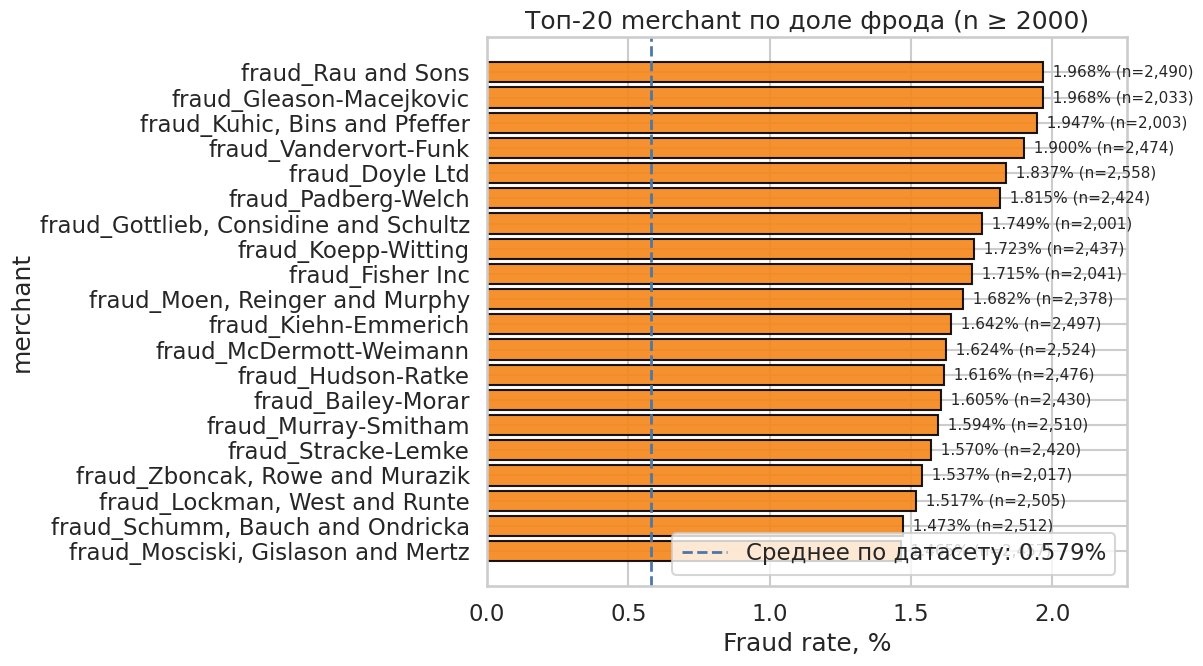

In [66]:
# Top merchants by fraud rate (с фильтром по min_n, чтобы не шуметь)
sns.set_theme(style="whitegrid", context="talk")

MIN_N = 2000   # порог по числу транзакций на мерчанта (попробуй 500/1000/5000)
TOP_K = 20

g = (df_train.groupby("merchant")["is_fraud"]
     .agg(n="size", rate="mean")
     .reset_index())

g = g[g["n"] >= MIN_N].copy()
g["rate_pct"] = g["rate"] * 100

# берём топ-K по fraud rate и сортируем для barh
g = g.sort_values("rate_pct", ascending=False).head(TOP_K).sort_values("rate_pct", ascending=True)

overall = df_train["is_fraud"].mean() * 100

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(g["merchant"], g["rate_pct"], color="#F58518", edgecolor="black", alpha=0.9)
ax.axvline(overall, color="#4C78A8", linestyle="--", linewidth=2,
           label=f"Среднее по датасету: {overall:.3f}%")

ax.set_title(f"Топ-{TOP_K} merchant по доле фрода (n ≥ {MIN_N})")
ax.set_xlabel("Fraud rate, %")
ax.set_ylabel("merchant")

ax.set_xlim(0, max(0.2, float(g["rate_pct"].max() * 1.15)))

for bar, p, n in zip(bars, g["rate_pct"], g["n"]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f"  {p:.3f}% (n={n:,})",
            va="center", ha="left", fontsize=11)

ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

График показывает мерчантов с наибольшей долей фрода среди тех, у кого достаточно много транзакций (**n ≥ 2000**), поэтому значения выглядят относительно надёжно. Для этих топ‑20 fraud rate находится примерно в диапазоне **~1.47–1.97%**, что существенно выше среднего по датасету **0.579%** (примерно в **2.5–3.4 раза**). Это означает, что признак `merchant` очень информативен: есть конкретные продавцы/точки, где риск фрода значительно выше фона.

# **Baseline**

Из‑за сильного дисбаланса классов (среднее `is_fraud` ≈ **0.005789**, т.е. ~0.58% фрода) основной метрикой логично взять **PR-AUC (Average Precision)** - она лучше отражает качество на редком классе. В качестве дополнительной можно смотреть **ROC-AUC**, но оптимизировать/сравнивать модели лучше по PR-AUC.

Ниже - **простой baseline** на CatBoost (без сложного препроцессинга) + **time-based split** (валидация на более позднем периоде), и расчёт PR-AUC/ROC-AUC и подбор порога по максимуму F1.

In [ ]:
df = df_train.sort_values("trans_date_trans_time").copy()
cut_idx = int(len(df) * 0.8)
train_df = df.iloc[:cut_idx]
valid_df = df.iloc[cut_idx:]

drop_cols = ["is_fraud", "trans_num", "first", "last", "street", "city"]
X_train = train_df.drop(columns=drop_cols, errors="ignore")
y_train = train_df["is_fraud"]
X_valid = valid_df.drop(columns=drop_cols, errors="ignore")
y_valid = valid_df["is_fraud"]

# CatBoost умеет работать с object-колонками как с категориальными
cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()

model = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.08,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=100,
    random_seed=42
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

proba = model.predict_proba(X_valid)[:, 1]

pr_auc = average_precision_score(y_valid, proba)
roc_auc = roc_auc_score(y_valid, proba)

# Подбор порога по максимуму F1
prec, rec, thr = precision_recall_curve(y_valid, proba)
f1 = 2 * (prec * rec) / (prec + rec + 1e-12)
best_i = np.nanargmax(f1)
best_thr = thr[max(best_i - 1, 0)]  # thr короче на 1

pred_05 = (proba >= 0.5).astype(int)
pred_best = (proba >= best_thr).astype(int)

print(f"Valid size: {len(y_valid):,} | Fraud rate: {y_valid.mean():.4%}")
print(f"PR-AUC (Average Precision): {pr_auc:.5f}")
print(f"ROC-AUC: {roc_auc:.5f}\n")

print("Threshold=0.50:",
      f"Precision={precision_score(y_valid, pred_05):.4f}",
      f"Recall={recall_score(y_valid, pred_05):.4f}",
      f"F1={f1_score(y_valid, pred_05):.4f}", sep=" | ")

print(f"Best F1 threshold≈{best_thr:.4f}:",
      f"Precision={precision_score(y_valid, pred_best):.4f}",
      f"Recall={recall_score(y_valid, pred_best):.4f}",
      f"F1={f1_score(y_valid, pred_best):.4f}", sep=" | ")

0:	test: 0.6677605	best: 0.6677605 (0)	total: 2.51s	remaining: 16m 42s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# предполагается, что уже есть:
# y_valid  (0/1)
# proba = model.predict_proba(X_valid)[:, 1]

X = 0.95  # минимальный precision для "ловим фрод, но не слишком много FP"

prec, rec, thr = precision_recall_curve(y_valid, proba)
prec_t, rec_t, thr_t = prec[:-1], rec[:-1], thr

f1_t = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-12)

# best F1
i_f1 = int(np.nanargmax(f1_t))
thr_f1 = float(thr_t[i_f1])

# best recall under precision constraint
mask = prec_t >= X
if np.any(mask):
    i_cand = np.where(mask)[0]
    i_constr = i_cand[np.lexsort((-thr_t[i_cand], -prec_t[i_cand], -rec_t[i_cand]))][0]
    thr_constr = float(thr_t[i_constr])
else:
    i_constr, thr_constr = None, None

# --- Plot ---
plt.figure(figsize=(12, 6))
plt.plot(thr_t, prec_t, label="Precision", color="#4C78A8", linewidth=2)
plt.plot(thr_t, rec_t,  label="Recall",    color="#F58518", linewidth=2)
plt.plot(thr_t, f1_t,   label="F1",        color="#54A24B", linewidth=2)

# vertical markers
plt.axvline(0.50, color="gray", linestyle="--", linewidth=1.8, label="thr=0.50")
plt.axvline(thr_f1, color="#54A24B", linestyle="--", linewidth=2,
            label=f"Best F1 thr≈{thr_f1:.3f}")

if thr_constr is not None:
    plt.axvline(thr_constr, color="black", linestyle="--", linewidth=2,
                label=f"Max Recall @ Precision≥{X:.2f}: thr≈{thr_constr:.3f}")
else:
    plt.text(0.02, 0.02, f"Нет порога с Precision ≥ {X:.2f}", transform=plt.gca().transAxes)

plt.title("Метрики в зависимости от порога классификации")
plt.xlabel("Threshold on proba")
plt.ylabel("Metric value")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# краткий вывод чисел в консоль
print(f"Best F1: thr={thr_f1:.6f} | Precision={prec_t[i_f1]:.4f} | Recall={rec_t[i_f1]:.4f} | F1={f1_t[i_f1]:.4f}")
if thr_constr is not None:
    print(f"Max Recall with Precision≥{X:.2f}: thr={thr_constr:.6f} | Precision={prec_t[i_constr]:.4f} | Recall={rec_t[i_constr]:.4f} | F1={f1_t[i_constr]:.4f}")

Зафиксировали первый baseline на CatBoost с time-based валидацией (последние 20% по времени). На валидации (259 335 наблюдений, fraud rate 0.593%) модель показывает очень высокое качество ранжирования: PR-AUC = 0.915 (ключевая метрика для редкого класса при среднем is_fraud≈0.005789) и ROC-AUC = 0.9969
. При стандартном пороге 0.5 получаем Precision=0.963 и Recall=0.747 (мало ложных срабатываний, но часть фрода пропускаем); при подборе порога под максимум F1 качество по балансу precision/recall улучшается (F1=0.8635, Recall=0.798). Порог на этом этапе не фиксируем — вернёмся к нему после выбора финальной метрики/бизнес-ограничений.

# **Работа с аномалиями и генерация признаков**

In [ ]:
# Берём только числовые колонки (исключим target)
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "is_fraud"]

def outlier_summary(s: pd.Series, z_thr=4.0):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    iqr_cnt = int(((s < lo) | (s > hi)).sum())

    mu, sd = s.mean(), s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        z_cnt = 0
    else:
        z = (s - mu) / sd
        z_cnt = int((np.abs(z) > z_thr).sum())

    return pd.Series({
        "n": int(s.shape[0]),
        "min": s.min(),
        "p01": s.quantile(0.01),
        "p50": s.median(),
        "p99": s.quantile(0.99),
        "max": s.max(),
        "iqr_lo": lo,
        "iqr_hi": hi,
        "iqr_outliers": iqr_cnt,
        "iqr_outliers_%": iqr_cnt / max(1, s.shape[0]) * 100,
        f"z>{z_thr}_outliers": z_cnt,
        f"z>{z_thr}_outliers_%": z_cnt / max(1, s.shape[0]) * 100,
    })

summary = pd.concat(
    {col: outlier_summary(df_train[col]) for col in num_cols},
    axis=1
).T

summary = summary.sort_values("iqr_outliers_%", ascending=False)

display(summary)
print("\nTop-5 по доле IQR-выбросов:")
display(summary.head(5)[["n","min","p01","p50","p99","max","iqr_outliers_%", "z>4.0_outliers_%"]])

- city_pop - очень “тяжёлый хвост” (IQR помечает ~18.7% как выбросы), это чаще не ошибки, а просто сильная асимметрия распределения (малые города vs мегаполисы).

- amt - кандидат на выбросы (max ~28,948), здесь выбросы могут быть и нормальными “крупными покупками”, и подозрительными.

In [ ]:
sns.set_theme(style="whitegrid", context="talk")

def iqr_bounds(s):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return float(q1 - 1.5*iqr), float(q3 + 1.5*iqr)

def plot_outliers(df, col, log_transform=True):
    s = df[col].dropna()
    lo, hi = iqr_bounds(s)

    if log_transform:
        x = np.log10(s + 1)
        lo_x, hi_x = np.log10(lo + 1), np.log10(hi + 1)
        xlabel = f"log10({col} + 1)"
    else:
        x = s
        lo_x, hi_x = lo, hi
        xlabel = col

    outlier_mask = (s < lo) | (s > hi)
    out_pct = outlier_mask.mean() * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios":[1.4, 1]})

    # histogram
    sns.histplot(x, bins=60, ax=axes[0], color="#4C78A8", alpha=0.85)
    axes[0].axvline(lo_x, color="black", linestyle="--", linewidth=2, label="IQR lower/upper")
    axes[0].axvline(hi_x, color="black", linestyle="--", linewidth=2)
    axes[0].set_title(f"{col}: распределение + IQR-границы (outliers ~{out_pct:.2f}%)")
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # boxplot
    sns.boxplot(x=x, ax=axes[1], color="#F58518", showfliers=False)
    axes[1].set_title("Boxplot (без точек)")
    axes[1].set_xlabel(xlabel)

    plt.tight_layout()
    plt.show()

    print(f"{col}: n={len(s):,} | min={s.min():,.3g} | p99={s.quantile(0.99):,.3g} | max={s.max():,.3g}")
    print(f"IQR bounds: [{lo:,.3g}, {hi:,.3g}] -> outliers: {outlier_mask.sum():,} ({out_pct:.2f}%)\n")
    print(lo_x, hi_x)

plot_outliers(df_train, "amt", log_transform=True)
plot_outliers(df_train, "city_pop", log_transform=True)


Для обеих переменных удалять строки нельзя: это приведёт к потере данных и смещению распределений, а “выбросы” здесь, судя по графикам, - естественная часть популяции.

**Добавим признаки на основе аномалий**

In [ ]:
def iqr_bounds(s: pd.Series):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return float(q1 - 1.5 * iqr), float(q3 + 1.5 * iqr)

def fit_anomaly_thresholds(df: pd.DataFrame, cols):
    th = {}
    for col in cols:
        lo, hi = iqr_bounds(df[col])
        log_col = np.log10(df[col] + 1)
        mu, sd = float(log_col.mean()), float(log_col.std(ddof=0))
        th[col] = {"iqr_lo": lo, "iqr_hi": hi, "log_mu": mu, "log_sd": sd}
    return th

def add_anomaly_features(df: pd.DataFrame, thresholds, z_thr=4.0, prefix="an_"):
    df = df.copy()
    flags = []

    for col, t in thresholds.items():
        # лог-версия (полезна и сама по себе)
        log_name = f"{prefix}log10_{col}"
        df[log_name] = np.log10(df[col] + 1)

        # IQR-флаги в исходной шкале
        f_hi = f"{prefix}{col}_iqr_hi"
        f_lo = f"{prefix}{col}_iqr_lo"
        df[f_hi] = (df[col] > t["iqr_hi"]).astype("int8")
        df[f_lo] = (df[col] < t["iqr_lo"]).astype("int8")
        flags += [f_hi, f_lo]

        # Z-score флаг в лог-шкале (устойчивее для тяжёлых хвостов)
        z = (df[log_name] - t["log_mu"]) / (t["log_sd"] + 1e-12)
        f_z = f"{prefix}{col}_z_gt_{str(z_thr).replace('.','_')}"
        df[f_z] = (z.abs() > z_thr).astype("int8")
        flags.append(f_z)

    # общий "счётчик аномалий" (сколько флагов сработало)
    df[f"{prefix}count_flags"] = df[flags].sum(axis=1).astype("int16")

    return df, flags

base_cols = ["amt", "city_pop"]  # можно расширить позже (distance_km и т.д.)

thresholds = fit_anomaly_thresholds(df_train, base_cols)

df_train_fe, an_flags = add_anomaly_features(df_train, thresholds, z_thr=4.0, prefix="an_")

# если df_test существует — применяем те же пороги
try:
    df_test_fe, _ = add_anomaly_features(df_test, thresholds, z_thr=4.0, prefix="an_")
except NameError:
    df_test_fe = None

print("Добавлены фичи-флаги:", an_flags)
print("Пример распределения количества флагов (train):")
display(df_train_fe["an_count_flags"].value_counts().sort_index().head(10))

print("\nДоли срабатываний флагов (train), %:")
display((df_train_fe[an_flags].mean() * 100).sort_values(ascending=False).round(3))

Большинство строк (~1,003,562) не имеют ни одного флага, у ~276k срабатывает ровно 1 флаг, у ~16.9k - 2 флага, и совсем редкие случаи (23 строки) - 3 флага. По долям срабатываний видно, что основные “аномалии” по IQR - это высокий city_pop (18.7%) и высокий amt (5.19%); Z>4 по amt в лог-шкале почти не встречается (0.008%), то есть это уже “супер-экстремальные” суммы.

In [ ]:
sns.set_theme(style="whitegrid", context="talk")

overall = df_train_fe["is_fraud"].mean()

# --- 1) Таблица по каждому флагу: n, fraud rate, lift ---
rows = []
for f in an_flags:
    for val in [0, 1]:
        sub = df_train_fe[df_train_fe[f] == val]
        n = len(sub)
        rate = sub["is_fraud"].mean() if n else np.nan
        rows.append({
            "feature": f,
            "value": val,
            "n": n,
            "fraud_rate_%": rate * 100,
            "lift_vs_overall": rate / overall if overall > 0 else np.nan
        })

flag_stats = pd.DataFrame(rows)
flag_stats_1 = flag_stats[flag_stats["value"] == 1].sort_values("lift_vs_overall", ascending=False)

display(flag_stats_1[["feature","n","fraud_rate_%","lift_vs_overall"]].round({"fraud_rate_%":4,"lift_vs_overall":3}))

# --- 2) Аналогично по счётчику флагов ---
cnt = (df_train_fe.groupby("an_count_flags")["is_fraud"]
       .agg(n="size", fraud_rate="mean")
       .reset_index())
cnt["fraud_rate_%"] = cnt["fraud_rate"] * 100
cnt["lift_vs_overall"] = cnt["fraud_rate"] / overall

display(cnt.round({"fraud_rate":6,"fraud_rate_%":4,"lift_vs_overall":3}))

# --- 3) Визуализация: fraud rate по сработавшим флагам + по count_flags ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Флаги (только value=1)
sns.barplot(
    data=flag_stats_1,
    x="fraud_rate_%",
    y="feature",
    color="#F58518",
    edgecolor="black",
    ax=axes[0]
)
axes[0].axvline(overall*100, color="#4C78A8", linestyle="--", linewidth=2, label=f"Overall: {overall*100:.3f}%")
axes[0].set_title("Fraud rate при срабатывании флага (value=1)")
axes[0].set_xlabel("Fraud rate, %")
axes[0].set_ylabel("")
axes[0].legend()

# Count flags
sns.barplot(
    data=cnt,
    x="an_count_flags",
    y="fraud_rate_%",
    color="#4C78A8",
    edgecolor="black",
    ax=axes[1]
)
axes[1].axhline(overall*100, color="#F58518", linestyle="--", linewidth=2, label=f"Overall: {overall*100:.3f}%")
axes[1].set_title("Fraud rate по количеству флагов")
axes[1].set_xlabel("an_count_flags")
axes[1].set_ylabel("Fraud rate, %")
axes[1].legend()

plt.tight_layout()
plt.show()

- Флаг “аномально большая сумма” (an_amt_iqr_hi) оказался самым информативным: при его срабатывании fraud rate 8.48% при среднем по датасету 0.579%, то есть lift ≈ 14.6×. Это очень сильный бизнес-сигнал: крупные (для распределения) суммы существенно чаще оказываются мошенническими.
- an_city_pop_iqr_hi почти не меняет риск (fraud rate 0.591%, lift ~1.02×) - то есть большой город сам по себе почти не увеличивает вероятность фрода (в рамках этого датасета). Его можно оставить “на всякий случай” или убрать как слабый признак - но вреда обычно не будет, если модель умеет отбирать.
- Z-флаг an_amt_z_gt_4_0 сработал всего 99 раз и не поймал фрод (0%), поэтому как отдельный признак сейчас выглядит бесполезным (слишком редкий/нестабильный). Аналогично нижние IQR-флаги для amt и city_pop вообще не срабатывают (0 строк) - их лучше удалить из набора фич.
- Очень хороший итоговый агрегатный признак - an_count_flags:
при 0 флагах fraud rate 0.148% (ниже среднего),
при 1 флаге 1.78% (lift ~3.1×),
при 2 флагах 6.59% (lift ~11.4×).
Это удобный “risk counter”: чем больше аномальных характеристик у транзакции, тем выше вероятность фрода.

In [ ]:
# Оставляем только полезные anomaly-features:
# - an_amt_iqr_hi
# - an_city_pop_iqr_hi (опционально)
# - an_count_flags
# Удаляем флаги, которые всегда 0 или почти всегда 0.

keep_flags = ["an_amt_iqr_hi", "an_city_pop_iqr_hi", "an_count_flags", "an_log10_amt", "an_log10_city_pop"]

cols_to_drop = [c for c in df_train_fe.columns if c.startswith("an_") and c not in keep_flags]

print("Удаляем anomaly-колонки:", cols_to_drop)

df_train_an = df_train_fe.drop(columns=cols_to_drop)
try:
    df_test_an = df_test_fe.drop(columns=cols_to_drop)
except NameError:
    df_test_an = None

print("Оставшиеся anomaly-колонки:", [c for c in df_train_an.columns if c.startswith("an_")])

**Генерация призников**

In [ ]:
# 4 региона Census (простой и популярный вариант)
REGION_MAP = {
    # Northeast
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
    "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",
    # Midwest
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest", "WI": "Midwest",
    "IA": "Midwest", "KS": "Midwest", "MN": "Midwest", "MO": "Midwest", "NE": "Midwest",
    "ND": "Midwest", "SD": "Midwest",
    # South
    "DE": "South", "FL": "South", "GA": "South", "MD": "South", "NC": "South", "SC": "South",
    "VA": "South", "DC": "South", "WV": "South", "AL": "South", "KY": "South", "MS": "South",
    "TN": "South", "AR": "South", "LA": "South", "OK": "South", "TX": "South",
    # West
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NV": "West", "NM": "West",
    "UT": "West", "WY": "West", "AK": "West", "CA": "West", "HI": "West", "OR": "West", "WA": "West",
}

def add_regime_calendar_features(df: pd.DataFrame, dt_col="trans_date_trans_time"):
    df = df.copy()
    df[dt_col] = pd.to_datetime(df[dt_col])

    # --- regime shift feature (до/после 2019-03) ---
    cut = pd.Timestamp("2019-03-01")
    df["is_pre_2019_03"] = (df[dt_col] < cut).astype("int8")

    # --- month as category (часто ловит сезонность/дрейф) ---
    df["year_month"] = df[dt_col].dt.to_period("M").astype(str)

    # --- US region from state ---
    df["us_region"] = df["state"].map(REGION_MAP).fillna("Unknown")

    # --- calendar features (US federal holidays) ---
    d = df[dt_col].dt.normalize()
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=d.min(), end=d.max()).normalize()

    df["is_holiday"] = d.isin(holidays).astype("int8")
    df["is_day_before_holiday"] = (d + pd.Timedelta(days=1)).isin(holidays).astype("int8")
    df["is_day_after_holiday"]  = (d - pd.Timedelta(days=1)).isin(holidays).astype("int8")

    # --- time flags ---
    dow = df[dt_col].dt.dayofweek
    hr = df[dt_col].dt.hour
    df["is_weekend"] = dow.isin([5, 6]).astype("int8")
    df["is_night"] = hr.isin([0, 1, 2, 3]).astype("int8")
    df["is_late_evening"] = hr.isin([22, 23]).astype("int8")
    df["is_high_risk_time"] = ((df["is_night"] == 1) | (df["is_late_evening"] == 1)).astype("int8")

    return df

df_train = add_regime_calendar_features(df_train)
df_test  = add_regime_calendar_features(df_test)

new_cols = [
    "is_pre_2019_03", "year_month", "us_region",
    "is_holiday", "is_day_before_holiday", "is_day_after_holiday",
    "is_weekend", "is_night", "is_late_evening", "is_high_risk_time"
]

print("Новые признаки добавлены:", new_cols)

# доли для бинарных признаков
bin_cols = [c for c in new_cols if c.startswith("is_")]
display((df_train[bin_cols].mean() * 100).round(2).to_frame("share_%"))

# распределение по регионам
display((df_train["us_region"].value_counts(normalize=True) * 100).round(2).to_frame("share_%"))

In [ ]:
EARTH_RADIUS_KM = 6371.0

def knn_nn1_distance_km(points_df, lat_col, lon_col):
    """
    points_df: DataFrame с колонками lat/lon (уникальные точки!)
    Возвращает DataFrame с теми же координатами + расстояние до ближайшей ДРУГОЙ точки (nn1_km)
    """
    pts = points_df[[lat_col, lon_col]].to_numpy(dtype=np.float64)
    pts_rad = np.radians(pts)

    # n_neighbors=2: 1-й сосед — сама точка (0), 2-й — ближайшая другая
    nn = NearestNeighbors(n_neighbors=2, metric="haversine", algorithm="ball_tree")
    nn.fit(pts_rad)
    dist_rad, idx = nn.kneighbors(pts_rad, return_distance=True)

    nn1_km = dist_rad[:, 1] * EARTH_RADIUS_KM
    out = points_df[[lat_col, lon_col]].copy()
    out["nn1_km"] = nn1_km
    return out

# --- 1) Уникальные точки по train (чтобы не подсматривать test) ---
cust_pts = df_train[["lat", "long"]].drop_duplicates().reset_index(drop=True)
merch_pts = df_train[["merch_lat", "merch_long"]].drop_duplicates().reset_index(drop=True)

cust_nn = knn_nn1_distance_km(cust_pts, "lat", "long").rename(columns={"nn1_km": "cust_nn1_km"})
merch_nn = knn_nn1_distance_km(merch_pts, "merch_lat", "merch_long").rename(columns={"nn1_km": "merch_nn1_km"})

# --- 2) “Плотность” в точке: сколько транзакций приходится на точную координату (train) ---
cust_cnt = (df_train.groupby(["lat", "long"]).size()
            .rename("cust_loc_txn_cnt").reset_index())
merch_cnt = (df_train.groupby(["merch_lat", "merch_long"]).size()
             .rename("merch_loc_txn_cnt").reset_index())

def add_geo_neighbor_features(df):
    df = df.copy()
    df = df.merge(cust_nn, on=["lat", "long"], how="left")
    df = df.merge(merch_nn, on=["merch_lat", "merch_long"], how="left")
    df = df.merge(cust_cnt, on=["lat", "long"], how="left")
    df = df.merge(merch_cnt, on=["merch_lat", "merch_long"], how="left")

    # если в test встретилась новая точка (не было в train) — заполним безопасно
    df["cust_loc_txn_cnt"] = df["cust_loc_txn_cnt"].fillna(0).astype("int32")
    df["merch_loc_txn_cnt"] = df["merch_loc_txn_cnt"].fillna(0).astype("int32")

    return df

df_train = add_geo_neighbor_features(df_train)
df_test  = add_geo_neighbor_features(df_test)

new_cols = ["cust_nn1_km", "merch_nn1_km", "cust_loc_txn_cnt", "merch_loc_txn_cnt"]
print("Добавлены признаки:", new_cols)
display(df_train[new_cols].describe().T)

In [ ]:
sns.set_theme(style="whitegrid", context="talk")

# 1) time-based split
df = df_train.sort_values("trans_date_trans_time").copy()
cut_idx = int(len(df) * 0.8)
train_df = df.iloc[:cut_idx].copy()
valid_df = df.iloc[cut_idx:].copy()

# 2) X/y + исключаем явные ID/PII (иначе важности могут быть "про запоминание")
drop_cols = ["is_fraud", "trans_num", "first", "last", "street"]
X_train = train_df.drop(columns=drop_cols, errors="ignore")
y_train = train_df["is_fraud"]
X_valid = valid_df.drop(columns=drop_cols, errors="ignore")
y_valid = valid_df["is_fraud"]

cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()

train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)

# 3) модель (можно те же параметры, что в baseline)
model = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.08,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

# 4) embedded importance: LossFunctionChange на validation
imp = model.get_feature_importance(valid_pool, type="LossFunctionChange")
imp_df = pd.DataFrame({"feature": X_train.columns, "importance": imp}).sort_values("importance", ascending=False)

display(imp_df.head(30))

plt.figure(figsize=(10, 8))
top = imp_df.head(25).sort_values("importance", ascending=True)
plt.barh(top["feature"], top["importance"], color="#F58518", edgecolor="black")
plt.title("Top-25 важнейших признаков (CatBoost, LossFunctionChange)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
# Оставляем топ-15 признаков по embedded importance (imp_df из предыдущей ячейки)

TOP_N = 15
top15_features = imp_df["feature"].head(TOP_N).tolist()

X_train_top15 = X_train[top15_features].copy()
X_valid_top15 = X_valid[top15_features].copy()

print("Top-15 features:", top15_features)
print("Shapes:", X_train_top15.shape, X_valid_top15.shape)

**3-й этап. Шаг 1**

Обучение двух типов моделей

In [ ]:
!pip install category_encoders

In [ ]:
df_train = df_train.where(df_train.trans_date_trans_time >= '2019-03-01')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_recall_curve
import category_encoders as ce

cols_to_keep = ['category', 'amt', 'is_high_risk_time', 'city', 'hour', 'dob']

X_train_sub = X_train[cols_to_keep].copy()
X_valid_sub = X_valid_top15[cols_to_keep].copy()

# Инженерия признаков
for df in [X_train_sub, X_valid_sub]:
    # Логарифмируем сумму (добавляем 1, чтобы избежать log(0))
    df['amt'] = np.log10(df['amt'] + 1)
    df['dob'] = pd.to_datetime(df['dob']).dt.year
    df['cat_hour'] = df['category'].astype(str) + "_" + df['hour'].astype(str)

ohe_cols = ['category']
woe_cols = ['city', 'cat_hour']
num_cols = ['amt', 'is_high_risk_time', 'hour', 'dob']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ohe_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

woe_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('woe', ce.WOEEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('ohe', ohe_transformer, ohe_cols),
        ('woe', woe_transformer, woe_cols)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train_sub, y_train)
X_valid_prep = preprocessor.transform(X_valid_sub)

ohe_feature_names = preprocessor.named_transformers_['ohe'].named_steps['ohe'].get_feature_names_out(ohe_cols)
feature_names_out = num_cols + list(ohe_feature_names) + woe_cols

X_train_df = pd.DataFrame(X_train_prep, columns=feature_names_out, index=X_train_sub.index)
X_valid_df = pd.DataFrame(X_valid_prep, columns=feature_names_out, index=X_valid_sub.index)

lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train_df, y_train)

proba_lr = lr_model.predict_proba(X_valid_df)[:, 1]
pr_auc_lr = average_precision_score(y_valid, proba_lr)
roc_auc_lr = roc_auc_score(y_valid, proba_lr)

prec, rec, thr = precision_recall_curve(y_valid, proba_lr)
f1 = 2 * (prec * rec) / (prec + rec + 1e-12)
best_i = np.nanargmax(f1)
best_thr = thr[max(best_i - 1, 0)]
pred_best_lr = (proba_lr >= best_thr).astype(int)

print(f"Logistic Regression ROC-AUC: {roc_auc_lr:.5f}")
print(f"Logistic Regression PR-AUC: {pr_auc_lr:.5f}")
print(f"Best F1 (thr={best_thr:.4f}): {f1_score(y_valid, pred_best_lr):.4f}")

In [ ]:
train_df[["is_fraud", "trans_num", "first", "last", "street", "city"]].head()

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score

cat_features_top15 = X_train_top15.select_dtypes(include=["object"]).columns.tolist()

train_pool_top15 = Pool(X_train_top15, y_train, cat_features=cat_features_top15)
valid_pool_top15 = Pool(X_valid_top15, y_valid, cat_features=cat_features_top15)

model_cb_top15 = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.08,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)
model_cb_top15.fit(train_pool_top15, eval_set=valid_pool_top15, use_best_model=True)
imp = model_cb.get_feature_importance(valid_pool, type="LossFunctionChange")
imp_df = pd.DataFrame({"feature": X_train.columns, "importance": imp}).sort_values("importance", ascending=False)

TOP_N = 15
top15_features = imp_df["feature"].head(TOP_N).tolist()

X_train_top15 = X_train[top15_features].copy()
X_valid_top15 = X_valid[top15_features].copy()

print(f"Топ-15 признаков: {top15_features}")

In [ ]:
proba_cb = model_cb_top15.predict_proba(X_valid_top15)[:, 1]
pr_auc_cb = average_precision_score(y_valid, proba_cb)
roc_auc_cb = roc_auc_score(y_valid, proba_cb)
prec_cb, rec_cb, thr_cb = precision_recall_curve(y_valid, proba_cb)
f1_cb = 2 * (prec_cb * rec_cb) / (prec_cb + rec_cb + 1e-12)
best_i_cb = np.nanargmax(f1_cb)
best_thr_cb = thr_cb[max(best_i_cb - 1, 0)]
pred_best_cb = (proba_cb >= best_thr_cb).astype(int)
print("--- Метрики CatBoost ---")
print(f"CatBoost ROC-AUC: {roc_auc_cb:.5f}")
print(f"CatBoost PR-AUC: {pr_auc_cb:.5f}")
print(f"CatBoost Best F1 (thr={best_thr_cb:.4f}): {f1_score(y_valid, pred_best_cb):.4f}")
print("------------------------")

In [ ]:
import warnings
warnings.filterwarnings("ignore")

X_sample_cat = X_valid_top15.reset_index(drop=True)

X_sample_lin = X_valid_df.reset_index(drop=True)

y_sample = y_valid.reset_index(drop=True)



**SHAP CatBoost**

In [ ]:
t0 = time.time()

explainer_cat = shap.TreeExplainer(model)
shap_values_cat = explainer_cat.shap_values(X_sample_cat)

print(f"Готово за {time.time()-t0:.1f}s")
print(f"shap_values shape: {np.array(shap_values_cat).shape}")

# global
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_cat,
    X_sample_cat,
    max_display=15,
    show=False,
    plot_type="dot"
)
plt.title("SHAP Summary Plot CatBoost (глобальный)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# global: bar
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_cat,
    X_sample_cat,
    max_display=15,
    show=False,
    plot_type="bar"
)
plt.title("SHAP Feature Importance (mean |SHAP|) CatBoost", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

shap_importance_cat = pd.DataFrame({
    "feature": X_sample_cat.columns,
    "mean_abs_shap": np.abs(shap_values_cat).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("Top-10 признаков CatBoost по SHAP:")
display(shap_importance_cat.head(10))

# local
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_cat[best_fraud_idx],
        base_values=explainer_cat.expected_value,
        data=X_sample_cat.iloc[best_fraud_idx].values,
        feature_names=X_sample_cat.columns.tolist()
    ),
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall CatBoost | idx={best_fraud_idx} (Fraud, P={proba_sample_cat[best_fraud_idx]:.3f})",
          fontsize=13)
plt.tight_layout()
plt.show()

# local: таблица
local_cat_shap = pd.DataFrame({
    "feature": X_sample_cat.columns,
    "shap_value": shap_values_cat[best_fraud_idx]
}).assign(abs_shap=lambda x: x["shap_value"].abs()).sort_values("abs_shap", ascending=False)

print("SHAP Local топ-10 — CatBoost:")
display(local_cat_shap[["feature", "shap_value"]].head(10))


**SHAP Logistic Regression**

In [ ]:
t0 = time.time()

explainer_lr = shap.LinearExplainer(
    lr_model,
    X_train_lin_df,
    feature_perturbation="interventional"
)
shap_values_lr = explainer_lr.shap_values(X_sample_lin)

print(f"Готово за {time.time()-t0:.1f}s")

# global
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_lr,
    X_sample_lin,
    max_display=15,
    show=False,
    plot_type="dot"
)
plt.title("SHAP Summary Plot Logistic Regression (глобальный)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# global: bar
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_lr,
    X_sample_lin,
    max_display=15,
    show=False,
    plot_type="bar"
)
plt.title("SHAP Feature Importance (mean |SHAP|) Logistic Regression", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

shap_importance_lr = pd.DataFrame({
    "feature": X_sample_lin.columns,
    "mean_abs_shap": np.abs(shap_values_lr).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("Top-10 признаков LogReg по SHAP:")
display(shap_importance_lr.head(10))

# local
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_lr[best_fraud_idx],
        base_values=explainer_lr.expected_value,
        data=X_sample_lin.iloc[best_fraud_idx].values,
        feature_names=X_sample_lin.columns.tolist()
    ),
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall Logistic Regression | idx={best_fraud_idx} (Fraud)",
          fontsize=13)
plt.tight_layout()
plt.show()

# local: таблица
local_lr_shap = pd.DataFrame({
    "feature": X_sample_lin.columns,
    "shap_value": shap_values_lr[best_fraud_idx]
}).assign(abs_shap=lambda x: x["shap_value"].abs()).sort_values("abs_shap", ascending=False)

print("SHAP Local топ-10 — LogReg:")
display(local_lr_shap[["feature", "shap_value"]].head(10))


Подготовка данных для LIME

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

X_sample_cat_lime = X_sample_cat.copy()

for col in X_sample_cat_lime.columns:
    if pd.api.types.is_datetime64_any_dtype(X_sample_cat_lime[col]):
        X_sample_cat_lime[col] = X_sample_cat_lime[col].astype(np.int64) // 10**9

lime_cat_cols = X_sample_cat_lime.select_dtypes(include="object").columns.tolist()
lime_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_sample_cat_lime[lime_cat_cols] = lime_enc.fit_transform(
    X_sample_cat_lime[lime_cat_cols].astype(str)
)

X_sample_lin_lime = X_sample_lin.copy()

proba_sample_cat = model.predict_proba(X_sample_cat)[:, 1]
fraud_indices  = np.where(y_sample == 1)[0]
best_fraud_idx = fraud_indices[np.argmax(proba_sample_cat[fraud_indices])]

print(f"Выбранное наблюдение для локальной интерпретации: индекс = {best_fraud_idx}")
print(f"Истинный класс: {y_sample.iloc[best_fraud_idx]} (1=Fraud)")
print(f"CatBoost P(fraud): {proba_sample_cat[best_fraud_idx]:.4f}")
print(f"LogReg P(fraud):   {lr_model.predict_proba(X_sample_lin_lime)[best_fraud_idx, 1]:.4f}")
print("Значения признаков (оригинал):")
display(X_sample_cat.iloc[[best_fraud_idx]].T.rename(columns={best_fraud_idx: "value"}))


**LIME CatBoost**

In [ ]:
cat_feature_indices = [
    list(X_sample_cat_lime.columns).index(c) for c in lime_cat_cols
]

def catboost_predict_fn(data):
    df_tmp = pd.DataFrame(data, columns=X_sample_cat_lime.columns)
    if lime_cat_cols:
        df_tmp[lime_cat_cols] = lime_enc.inverse_transform(
            df_tmp[lime_cat_cols].clip(-1).round().astype(int)
        )
    return model.predict_proba(df_tmp)

explainer_lime_cat = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_sample_cat_lime.values.astype(float),
    feature_names=X_sample_cat_lime.columns.tolist(),
    categorical_features=cat_feature_indices,
    class_names=["Not Fraud", "Fraud"],
    mode="classification",
    random_state=42
)

# --- global ---
N_LIME = 100
lime_imp_cat = {}

print(f"Считаем LIME CatBoost для {N_LIME} наблюдений...")
t0 = time.time()

for i in range(N_LIME):
    exp = explainer_lime_cat.explain_instance(
        X_sample_cat_lime.values[i].astype(float),
        catboost_predict_fn,
        num_features=15,
        labels=(1,)
    )
    for feat, val in exp.as_list(label=1):
        lime_imp_cat[feat] = lime_imp_cat.get(feat, []) + [abs(val)]

    if (i + 1) % 25 == 0:
        print(f"[{i+1}/{N_LIME}] elapsed: {time.time()-t0:.1f}s")

print(f"Готово за {time.time()-t0:.1f}s")

lime_df_cat = pd.DataFrame([
    {"feature_lime": k, "mean_abs_lime": np.mean(v)}
    for k, v in lime_imp_cat.items()
]).sort_values("mean_abs_lime", ascending=False).reset_index(drop=True)

print("Top-10 LIME признаков — CatBoost:")
display(lime_df_cat.head(10))

# global plot
fig, ax = plt.subplots(figsize=(10, 6))
top = lime_df_cat.head(15).sort_values("mean_abs_lime", ascending=True)
ax.barh(top["feature_lime"], top["mean_abs_lime"],
        color="#4C78A8", edgecolor="black", alpha=0.85)
ax.set_title("LIME Global — CatBoost (агрегация по 100 наблюдениям)", fontsize=13)
ax.set_xlabel("Mean |LIME weight|")
plt.tight_layout()
plt.show()

# --- local ---
exp_local_cat = explainer_lime_cat.explain_instance(
    X_sample_cat_lime.values[best_fraud_idx].astype(float),
    catboost_predict_fn,
    num_features=15,
    labels=(1,)
)

fig = exp_local_cat.as_pyplot_figure(label=1)
fig.set_size_inches(10, 6)
plt.title(f"LIME Local — CatBoost | idx={best_fraud_idx} (Fraud, P={proba_sample_cat[best_fraud_idx]:.3f})",
          fontsize=12)
plt.tight_layout()
plt.show()

local_cat_lime = pd.DataFrame(
    exp_local_cat.as_list(label=1),
    columns=["feature_rule", "lime_weight"]
).assign(abs_w=lambda x: x["lime_weight"].abs()).sort_values("abs_w", ascending=False)

print("LIME Local топ-10 — CatBoost:")
display(local_cat_lime[["feature_rule", "lime_weight"]].head(10))

# local plot
fig, ax = plt.subplots(figsize=(10, 6))
top = local_cat_lime.head(10).sort_values("abs_w", ascending=True)
colors_bar = ["#E63946" if w > 0 else "#457B9D" for w in top["lime_weight"]]
ax.barh(top["feature_rule"], top["lime_weight"],
        color=colors_bar, edgecolor="black", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"LIME Local — CatBoost | idx={best_fraud_idx} (Fraud)", fontsize=12)
ax.set_xlabel("LIME weight (>0 = Fraud)")
plt.tight_layout()
plt.show()


**LIME LogReg**

In [ ]:
def logreg_predict_fn(data):
    return lr_model.predict_proba(data)

explainer_lime_lr = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_sample_lin_lime.values.astype(float),
    feature_names=X_sample_lin_lime.columns.tolist(),
    class_names=["Not Fraud", "Fraud"],
    mode="classification",
    random_state=42
)

# --- global ---
N_LIME = 100
lime_imp_lr = {}

print(f"Считаем LIME LogReg для {N_LIME} наблюдений...")
t0 = time.time()

for i in range(N_LIME):
    exp = explainer_lime_lr.explain_instance(
        X_sample_lin_lime.values[i].astype(float),
        logreg_predict_fn,
        num_features=15,
        labels=(1,)
    )
    for feat, val in exp.as_list(label=1):
        lime_imp_lr[feat] = lime_imp_lr.get(feat, []) + [abs(val)]

    if (i + 1) % 25 == 0:
        print(f"[{i+1}/{N_LIME}] elapsed: {time.time()-t0:.1f}s")

print(f"Готово за {time.time()-t0:.1f}s")

lime_df_lr = pd.DataFrame([
    {"feature_lime": k, "mean_abs_lime": np.mean(v)}
    for k, v in lime_imp_lr.items()
]).sort_values("mean_abs_lime", ascending=False).reset_index(drop=True)

print("Top-10 LIME признаков — LogReg:")
display(lime_df_lr.head(10))

# global plot
fig, ax = plt.subplots(figsize=(10, 6))
top = lime_df_lr.head(15).sort_values("mean_abs_lime", ascending=True)
ax.barh(top["feature_lime"], top["mean_abs_lime"],
        color="#F58518", edgecolor="black", alpha=0.85)
ax.set_title("LIME Global — LogReg (агрегация по 100 наблюдениям)", fontsize=13)
ax.set_xlabel("Mean |LIME weight|")
plt.tight_layout()
plt.show()

# --- local ---
exp_local_lr = explainer_lime_lr.explain_instance(
    X_sample_lin_lime.values[best_fraud_idx].astype(float),
    logreg_predict_fn,
    num_features=15,
    labels=(1,)
)

fig = exp_local_lr.as_pyplot_figure(label=1)
fig.set_size_inches(10, 6)
plt.title(f"LIME Local — LogReg | idx={best_fraud_idx} (Fraud)",
          fontsize=12)
plt.tight_layout()
plt.show()

local_lr_lime = pd.DataFrame(
    exp_local_lr.as_list(label=1),
    columns=["feature_rule", "lime_weight"]
).assign(abs_w=lambda x: x["lime_weight"].abs()).sort_values("abs_w", ascending=False)

print("LIME Local топ-10 — LogReg:")
display(local_lr_lime[["feature_rule", "lime_weight"]].head(10))

# local plot
fig, ax = plt.subplots(figsize=(10, 6))
top = local_lr_lime.head(10).sort_values("abs_w", ascending=True)
colors_bar = ["#E63946" if w > 0 else "#457B9D" for w in top["lime_weight"]]
ax.barh(top["feature_rule"], top["lime_weight"],
        color=colors_bar, edgecolor="black", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"LIME Local — LogReg | idx={best_fraud_idx} (Fraud)", fontsize=12)
ax.set_xlabel("LIME weight (>0 = Fraud)")
plt.tight_layout()
plt.show()


## Сравнение CatBoost и Logistic Regression

### Совпадение ключевых признаков

Ключевые признаки в значительной мере совпадают между CatBoost и LogReg:

| Признак           | SHAP CatBoost | SHAP LogReg | LIME CatBoost | Вывод         |
|-------------------|---------------|-------------|---------------|---------------|
| amt               | #2 (1.59)     | #5 (0.88)   | #1 (0.40)     | совпадает     |
| category          | #1 (1.68)     | #4 (1.09)   | #4 (0.27)     | совпадает     |
| is_high_risk_time | #3 (0.94)     | #2 (1.38)   | #5 (0.06)     | совпадает     |
| city              | #4 (0.26)     | #2 (1.49)   | #2–3 (0.37)   | совпадает     |
| hour              | #6 (0.20)     | #6 (0.65)   | #4 (0.07)     | совпадает     |
| merchant          | вне топ-10    | #4 (0.96)   | #5–8 (0.21)   | частично      |

**Вывод:** топ-5 признаков обеих моделей пересекаются на 4 из 5 позиций
(amt, category, is_high_risk_time, city/hour). Это подтверждает, что данные
признаки несут реальный сигнал, а не артефакт конкретного алгоритма.

---

### Различия между моделями

**CatBoost (SHAP):**
- category и amt доминируют с большим отрывом (1.68 и 1.59 vs 0.94 у третьего)
- dob, trans_date_trans_time, job входят в топ-10 — CatBoost улавливает
  нелинейные взаимодействия с этими признаками
- is_high_risk_time на третьем месте — модель хорошо улавливает временной паттерн

**LogReg (SHAP):**
- amt_pow_imp (степенная трансформация amt) выходит на первое место (2.40),
  обгоняя оригинальный amt — степенная трансформация усилила сигнал для
  линейной модели
- is_high_risk_time_pow_imp и city_pow_imp также в топ-10 — степенные
  трансформации дают линейной модели дополнительный сигнал
- merchant значительно важнее для LogReg (#4, 0.96) чем для CatBoost
- LogReg не улавливает сигнал от dob и trans_date_trans_time — линейная
  модель не может извлечь нелинейные паттерны из этих признаков

---

### Направления влияния (SHAP)

**CatBoost:**
- Высокий amt сильно толкает к фроду (положительный SHAP)
- Определённые категории (shopping_net, misc_net) ведут к фроду
- is_high_risk_time = 1 (ночь/поздний вечер) ведет к фроду
- Некоторые city/job/merchant ведут как к фроду, так и против (зависит от значения)

**LogReg:**
- amt_pow_imp: высокие значения ведут к фроду (аналогично CatBoost)
- is_high_risk_time ведет к фроду (совпадает)
- category ведеи к фроду для высокорисковых категорий (совпадает)
- Направления в целом согласуются с CatBoost, но эффекты слабее из-за
  неспособности модели улавливать нелинейности

---

## Локальная интерпретация: транзакция 1053 (Fraud)

Эта транзакция с максимальной предсказанной вероятностью фрода по CatBoost.

---

### Определяющие признаки: сравнение методов

| Признак           | SHAP CatBoost | SHAP LogReg   | LIME CatBoost      |
|-------------------|---------------|---------------|--------------------|
| amt               | +4.70 (#2)    | -5.50 (#2)    | amt > 175.18 (#1)  |
| category          | +8.01 (#1)    | -1.96 (#4)    | category=11 (#7)   |
| city              | +4.68 (#3)    | +0.68 (#10)   | city=172 (#2)      |
| is_high_risk_time | +1.06 (#5)    | +2.26 (#3)    | 0<is_high..<=1 (#5)|
| hour              | +0.93 (#6)    | -1.03 (#7)    | hour > 21 (#4)     |
| job               | +1.10 (#4)    | вне топ-10    | job=89 (#3)        |
| amt_pow_imp       | —             | +16.99 (#1)   | —                  |

---

### Анализ совпадений и расхождений

**Совпадения:**
- amt, category, city и is_high_risk_time присутствуют в топ признаках
  всех трёх методов — это сильный сигнал их реальной важности для данного
  конкретного наблюдения
- hour > 21 в LIME соответствует is_high_risk_time в SHAP — разные методы
  описывают один и тот же паттерн (поздний час = риск) разными способами
- LIME подтверждает: amt > 175.18 — является ключевым
  триггером, что согласуется с SHAP CatBoost (+4.70)

**Расхождения:**
- amt в SHAP LogReg имеет отрицательное значение (-5.50), тогда как в
  SHAP CatBoost — положительное (+4.70). Это объясняется тем, что LogReg
  видит amt и amt_pow_imp как два отдельных коррелирующих признака,
  и их суммарный эффект (+16.99 - 5.50 = +11.49) всё равно направлен
  к фроду, то есть противоречия нет, это артефакт мультиколлинеарности
- category в SHAP LogReg отрицательный (-1.96): после WOE-преобразования
  направление влияния может инвертироваться относительно оригинального
  признака; в CatBoost category даёт максимальный положительный вклад (+8.01)
- job важен для CatBoost (SHAP +1.10, LIME #3) но отсутствует в топ-10
  LogReg,  линейная модель не извлекает нелинейный сигнал из профессии

**Какой метод надёжнее:**
- SHAP CatBoost наиболее согласован и интерпретируем: category + amt + city
  — три главных драйвера фрода в данном наблюдении
- LIME даёт удобные пороговые правила (amt > 175.18, hour > 21),
  но коды категорий (city=172, job=89) требуют расшифровки
- SHAP LogReg менее надёжен из-за мультиколлинеарности между оригинальными
  и степенными признаками (amt vs amt_pow_imp)

**3-й этап. Шаг 2**

In [ ]:
def get_shap_embeddings_catboost(model, X, explainer=None):
    if explainer is None:
        explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X)
    shap_df = pd.DataFrame(
        shap_vals,
        columns=[f"shap_{c}" for c in X.columns],
        index=X.index
    )
    return shap_df, explainer


def get_shap_embeddings_logreg(lr_model, X_train_ref, X, explainer=None):
    if explainer is None:
        explainer = shap.LinearExplainer(
            lr_model,
            X_train_ref,
            feature_perturbation="interventional"
        )
    shap_vals = explainer.shap_values(X)
    shap_df = pd.DataFrame(
        shap_vals,
        columns=[f"shap_{c}" for c in X.columns],
        index=X.index
    )
    return shap_df, explainer

print("Вычисляем SHAP-эмбеддинги CatBoost...")
t0 = time.time()
shap_emb_cat, explainer_cat = get_shap_embeddings_catboost(model, X_sample_cat)
print(f"Готово за {time.time()-t0:.1f}s | shape: {shap_emb_cat.shape}")

print("Вычисляем SHAP-эмбеддинги LogReg...")
t0 = time.time()
shap_emb_lr, explainer_lr = get_shap_embeddings_logreg(
    lr_model, X_train_lin_df, X_sample_lin
)
print(f"Готово за {time.time()-t0:.1f}s | shape: {shap_emb_lr.shape}")

shap_emb_cat["is_fraud"] = y_sample.values
shap_emb_lr["is_fraud"]  = y_sample.values

display(shap_emb_cat.head(3))


Выявим сдвиги и аномалии в SHAP-эмбеддингах

In [ ]:
shap_feat_cols_cat = [c for c in shap_emb_cat.columns if c.startswith("shap_")]
shap_feat_cols_lr  = [c for c in shap_emb_lr.columns  if c.startswith("shap_")]

# --- Средние SHAP по классам ---
shap_by_class_cat = (shap_emb_cat
    .groupby("is_fraud")[shap_feat_cols_cat]
    .mean()
    .T
    .rename(columns={0: "mean_shap_clean", 1: "mean_shap_fraud"})
)
shap_by_class_cat["delta"] = (
    shap_by_class_cat["mean_shap_fraud"] - shap_by_class_cat["mean_shap_clean"]
)
shap_by_class_cat = shap_by_class_cat.sort_values("delta", key=abs, ascending=False)

print("Топ-10 признаков с наибольшим сдвигом SHAP (fraud vs clean) — CatBoost:")
display(shap_by_class_cat.head(10).round(4))

# визуализация сдвига
fig, ax = plt.subplots(figsize=(12, 6))
top = shap_by_class_cat.head(15).sort_values("delta", ascending=True)
colors_bar = ["#E63946" if d > 0 else "#457B9D" for d in top["delta"]]
ax.barh(top.index.str.replace("shap_", ""), top["delta"],
        color=colors_bar, edgecolor="black", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Сдвиг SHAP: fraud — clean (CatBoost)", fontsize=13)
ax.set_xlabel("Delta mean SHAP (fraud - clean)")
plt.tight_layout()
plt.show()

# --- Норма SHAP-вектора как скор аномальности ---
shap_emb_cat["shap_norm"] = np.linalg.norm(
    shap_emb_cat[shap_feat_cols_cat].values, axis=1
)
shap_emb_lr["shap_norm"] = np.linalg.norm(
    shap_emb_lr[shap_feat_cols_lr].values, axis=1
)

# распределение нормы по классам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, emb, title in zip(
    axes,
    [shap_emb_cat, shap_emb_lr],
    ["CatBoost", "LogReg"]
):
    for label, color, name in [(0, "#4C78A8", "Clean"), (1, "#F58518", "Fraud")]:
        subset = emb[emb["is_fraud"] == label]["shap_norm"]
        ax.hist(subset, bins=50, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(f"Норма SHAP-вектора по классам — {title}", fontsize=12)
    ax.set_xlabel("SHAP")
    ax.set_ylabel("Плотность")
    ax.legend()

plt.tight_layout()
plt.show()

# --- Наблюдения с экстремальной нормой SHAP ---
thr_cat = shap_emb_cat["shap_norm"].quantile(0.99)
thr_lr  = shap_emb_lr["shap_norm"].quantile(0.99)

anomalies_cat = shap_emb_cat[shap_emb_cat["shap_norm"] > thr_cat]
anomalies_lr  = shap_emb_lr[shap_emb_lr["shap_norm"]  > thr_lr]

print(f"Аномалии CatBoost: {len(anomalies_cat)} наблюдений")
print(f"Доля фрода среди аномалий CatBoost: {anomalies_cat['is_fraud'].mean():.2%}")
print(f"Аномалии LogReg): {len(anomalies_lr)} наблюдений")
print(f"Доля фрода среди аномалий LogReg: {anomalies_lr['is_fraud'].mean():.2%}")

# --- 4) Индексы аномалий для очистки ---
anomaly_indices_cat = anomalies_cat.index.tolist()
print(f"Индексы аномальных наблюдений (CatBoost): {anomaly_indices_cat[:10]}...")


In [ ]:
print("Вычисляем SHAP-нормы на полном train...")
t0 = time.time()

# берём подвыборку train для скорости
TRAIN_SHAP_SIZE = 50000
idx_tr_fraud = np.where(y_train == 1)[0]
idx_tr_clean = np.where(y_train == 0)[0]

n_tr_fraud = min(len(idx_tr_fraud), 2000)
n_tr_clean = TRAIN_SHAP_SIZE - n_tr_fraud

idx_tr_sample = np.concatenate([
    np.random.choice(idx_tr_fraud, n_tr_fraud, replace=False),
    np.random.choice(idx_tr_clean, n_tr_clean, replace=False)
])

X_train_shap_sample = X_train.iloc[idx_tr_sample].reset_index(drop=True)
y_train_shap_sample = y_train.iloc[idx_tr_sample].reset_index(drop=True)

shap_train_df, _ = get_shap_embeddings_catboost(model, X_train_shap_sample, explainer_cat)
shap_train_df["shap_norm"] = np.linalg.norm(
    shap_train_df[[c for c in shap_train_df.columns if c.startswith("shap_")]].values,
    axis=1
)

print(f"Готово за {time.time()-t0:.1f}s")

thr_train = shap_train_df["shap_norm"].quantile(0.99)
normal_mask = shap_train_df["shap_norm"] <= thr_train

X_train_clean = X_train_shap_sample[normal_mask].reset_index(drop=True)
y_train_clean = y_train_shap_sample[normal_mask].reset_index(drop=True)

print(f"Train до очистки:  {len(X_train_shap_sample):,}")
print(f"Train после очистки: {len(X_train_clean):,}")
print(f"Удалено: {(~normal_mask).sum():,} наблюдений")
print(f"Доля фрода до:   {y_train_shap_sample.mean():.4%}")
print(f"Доля фрода после: {y_train_clean.mean():.4%}")

# переобучаем модель на очищенных данных
cat_features_clean = X_train_clean.select_dtypes(include="object").columns.tolist()

model_clean = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.08,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

model_clean.fit(
    X_train_clean, y_train_clean,
    cat_features=cat_features_clean,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

# метрики до и после
proba_original = model.predict_proba(X_valid)[:, 1]
proba_clean    = model_clean.predict_proba(X_valid)[:, 1]

pr_auc_orig  = average_precision_score(y_valid, proba_original)
pr_auc_clean = average_precision_score(y_valid, proba_clean)
roc_orig     = roc_auc_score(y_valid, proba_original)
roc_clean    = roc_auc_score(y_valid, proba_clean)

print("Сравнение метрик до и после очистки:")
results_df = pd.DataFrame({
    "Модель":   ["CatBoost original", "CatBoost clean"],
    "PR-AUC":   [pr_auc_orig,  pr_auc_clean],
    "ROC-AUC":  [roc_orig,     roc_clean],
})
display(results_df.round(5))


Очистка через SHAP-аномалии **не улучшила** качество модели, обе метрики
незначительно просели.
Причина очевидна из статистики удалённых наблюдений: доля фрода среди
удалённых 500 строк составила ~67%, то есть мы удалили не шум, а реальные фрод-кейсы с экстремальными SHAP-значениями. Именно эти наблюдения являются
наиболее показательными примерами фрода и их удаление лишает модель
полезного сигнала.


Кластеризуем эмбеддинги

In [ ]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

X_shap = shap_emb_cat[shap_feat_cols_cat].copy()
labels_true = shap_emb_cat["is_fraud"].values

scaler_shap = StandardScaler()
X_shap_scaled = scaler_shap.fit_transform(X_shap)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_shap_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")
k = 10
nn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
nn.fit(X_shap_scaled)
distances, _ = nn.kneighbors(X_shap_scaled)
k_distances = np.sort(distances[:, k-1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, color="#4C78A8", linewidth=1.5)
ax.set_title(f"k-distance plot (k={k}) — выбор eps для DBSCAN")
ax.set_xlabel("Точки (отсортированы по убыванию)")
ax.set_ylabel(f"{k}-е расстояние до соседа")
ax.axhline(y=np.percentile(k_distances, 90), color="#F58518",
           linestyle="--", label=f"p90 = {np.percentile(k_distances, 90):.2f}")
ax.axhline(y=np.percentile(k_distances, 95), color="#E63946",
           linestyle="--", label=f"p95 = {np.percentile(k_distances, 95):.2f}")
ax.legend()
plt.tight_layout()
plt.show()

eps_auto = float(np.percentile(k_distances, 90))
print(f"Выбранный eps = {eps_auto:.3f}")

# --- KMeans ---
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_shap_scaled)

# --- DBSCAN ---
dbscan = DBSCAN(eps=eps_auto, min_samples=k, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_shap_scaled)
n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db    = (labels_dbscan == -1).sum()
print(f"DBSCAN: кластеров={n_clusters_db}, шум={n_noise_db} ({n_noise_db/len(labels_dbscan):.1%})")

# --- Agglomerative ---
agglo = AgglomerativeClustering(n_clusters=4)
labels_agglo = agglo.fit_predict(X_shap_scaled)

# --- Визуализация ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plots = [
    (labels_true,   "Истинные классы (0=Clean, 1=Fraud)"),
    (labels_kmeans, "KMeans (k=4)"),
    (labels_dbscan, f"DBSCAN (eps={eps_auto:.2f}, шум={n_noise_db})"),
    (labels_agglo,  "Agglomerative (k=4)"),
]

for ax, (labels, title) in zip(axes.flat, plots):
    unique_labels = sorted(set(labels))
    cmap = plt.cm.get_cmap("tab10", len(unique_labels))
    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        name = "Fraud" if (title.startswith("Истинные") and lbl == 1) else \
               "Clean" if (title.startswith("Истинные") and lbl == 0) else \
               f"Cluster {lbl}" if lbl != -1 else "Noise"
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[cmap(i)], label=name, alpha=0.5, s=15)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(markerscale=2, fontsize=9)

plt.suptitle("SHAP-эмбеддинги: PCA 2D + кластеризация", fontsize=14)
plt.tight_layout()
plt.show()

# --- Fraud rate по кластерам ---
for labels, name in [
    (labels_kmeans, "KMeans"),
    (labels_dbscan, "DBSCAN"),
    (labels_agglo,  "Agglomerative")
]:
    df_cl = pd.DataFrame({
        "cluster":  labels,
        "is_fraud": labels_true
    })
    stats = (df_cl.groupby("cluster")["is_fraud"]
             .agg(n="size", fraud_rate="mean")
             .reset_index())
    stats["fraud_rate_%"] = stats["fraud_rate"] * 100
    print(f"Fraud rate по кластерам — {name}:")
    display(stats.round(4))


KMeans разделил пространство SHAP-эмбеддингов очень чётко:
кластеры 2 и 3 — практически полностью фрод, кластеры 0 и 1 — чистые.
Это говорит о том, что SHAP-эмбеддинги хорошо разделяют классы в
пространстве признаков.

DBSCAN выявил несколько компактных фрод-кластеров (1, 2, 3) с
fraud rate 100% — это потенциально разные паттерны мошенничества.
Шумовые точки (-1) тоже преимущественно фрод (70%) — аномальные
транзакции, не вписывающиеся ни в один плотный кластер.



У иерархического результат близок к KMeans: чёткое разделение на один большой чистый кластер и несколько фрод-кластеров разного размера.

In [ ]:
print("Вычисляем SHAP-эмбеддинги для train-сэмпла...")
t0 = time.time()

shap_train_full, _ = get_shap_embeddings_catboost(
    model, X_train_shap_sample, explainer_cat
)
shap_train_cols = [c for c in shap_train_full.columns if c.startswith("shap_")]

scaler_cl = StandardScaler()
X_shap_train_scaled = scaler_cl.fit_transform(shap_train_full[shap_train_cols].values)

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_final.fit(X_shap_train_scaled)

print(f"Готово за {time.time()-t0:.1f}s")
print(f"Кластеры на train: {pd.Series(kmeans_final.labels_).value_counts().to_dict()}")

print("Вычисляем SHAP-эмбеддинги для valid...")
t0 = time.time()

shap_valid_full, _ = get_shap_embeddings_catboost(model, X_valid, explainer_cat)
shap_valid_cols = [c for c in shap_valid_full.columns if c.startswith("shap_")]
X_shap_valid_scaled = scaler_cl.transform(shap_valid_full[shap_valid_cols].values)

print(f"Готово за {time.time()-t0:.1f}s")

X_train_cl = X_train_shap_sample.copy()
X_train_cl["shap_cluster"] = kmeans_final.labels_

X_valid_cl = X_valid.copy()
X_valid_cl["shap_cluster"] = kmeans_final.predict(X_shap_valid_scaled)

cl_valid_stats = (pd.DataFrame({
    "cluster":  X_valid_cl["shap_cluster"],
    "is_fraud": y_valid.values
})
.groupby("cluster")["is_fraud"]
.agg(n="size", fraud_rate="mean")
.reset_index())
cl_valid_stats["fraud_rate_%"] = cl_valid_stats["fraud_rate"] * 100

print("Fraud rate по кластерам в valid:")
display(cl_valid_stats.round(4))

# переобучаем CatBoost
cat_features_cl = X_train_cl.select_dtypes(include="object").columns.tolist()

model_with_cluster = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.08,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

model_with_cluster.fit(
    X_train_cl, y_train_shap_sample,
    cat_features=cat_features_cl,
    eval_set=(X_valid_cl, y_valid),
    use_best_model=True
)

# метрики
proba_original = model.predict_proba(X_valid)[:, 1]
proba_clean = model_clean.predict_proba(X_valid)[:, 1]
proba_with_cluster = model_with_cluster.predict_proba(X_valid_cl)[:, 1]

pr_auc_orig = average_precision_score(y_valid, proba_original)
pr_auc_clean = average_precision_score(y_valid, proba_clean)
pr_auc_cl = average_precision_score(y_valid, proba_with_cluster)

roc_orig = roc_auc_score(y_valid, proba_original)
roc_clean = roc_auc_score(y_valid, proba_clean)
roc_cl = roc_auc_score(y_valid, proba_with_cluster)

print("Итоговое сравнение метрик:")
results_final = pd.DataFrame({
    "Модель": [
        "CatBoost original (full train)",
        "CatBoost clean (SHAP outliers removed)",
        "CatBoost + shap_cluster (KMeans k=4)"
    ],
    "PR-AUC":  [pr_auc_orig,  pr_auc_clean,  pr_auc_cl],
    "ROC-AUC": [roc_orig,     roc_clean,     roc_cl],
})
display(results_final.round(5))

imp_cl = pd.DataFrame({
    "feature":    X_train_cl.columns,
    "importance": model_with_cluster.get_feature_importance()
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Важность shap_cluster в модели:")
display(imp_cl[imp_cl["feature"] == "shap_cluster"])
print("Top-10 признаков:")
display(imp_cl.head(10))


Добавление shap_cluster **значительно ухудшило** PR-AUC, несмотря на то что кластер вышел на первое место по важности.

Это скорее всего произошло из-за утечки информации: кластеры были получены через SHAP-эмбеддинги модели, обученной на тех же данных, то есть кластер фактически кодирует предсказание самой модели. Далее модель увидела кластер как очень сильный сигнал и начала опираться на него вместо исходных признаков

Все три эксперимента показали, что оригинальная модель на полном train является лучшей. Ни очистка через SHAP-аномалии, ни добавление кластера не дали прироста качества.

Причины:
- Очистка удаляла реальные фрод-кейсы, а не шум
- shap_cluster внёс data leakage и переобучение
- Модель обучалась на сэмпле вместо полного train



**3-й этап. Шаг 3**

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

SKF_N = 3
skf = StratifiedKFold(n_splits=SKF_N, shuffle=False)

X_cv = X_train_shap_sample.reset_index(drop=True)
y_cv = y_train_shap_sample.reset_index(drop=True)

cv_results = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f"Fold {fold+1}/{SKF_N}...")

    X_tr_fold  = X_cv.iloc[tr_idx]
    X_val_fold = X_cv.iloc[val_idx]
    y_tr_fold  = y_cv.iloc[tr_idx]
    y_val_fold = y_cv.iloc[val_idx]

    # обучаем CatBoost на фолде
    cat_f = X_tr_fold.select_dtypes(include="object").columns.tolist()
    m_fold = CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.08,
        loss_function="Logloss", random_seed=42, verbose=0
    )
    m_fold.fit(X_tr_fold, y_tr_fold, cat_features=cat_f)

    # SHAP-эмбеддинги на val
    shap_tr_fold, exp_fold = get_shap_embeddings_catboost(m_fold, X_tr_fold)
    shap_val_fold, _       = get_shap_embeddings_catboost(m_fold, X_val_fold, exp_fold)
    shap_cols_fold = [c for c in shap_val_fold.columns if c.startswith("shap_")]

    # базовые метрики CatBoost
    proba_fold = m_fold.predict_proba(X_val_fold)[:, 1]
    pr_base  = average_precision_score(y_val_fold, proba_fold)
    roc_base = roc_auc_score(y_val_fold, proba_fold)

    # --- вариант A: LogReg только на SHAP-эмбеддингах ---
    sc_a = StandardScaler()
    X_tr_a  = sc_a.fit_transform(shap_tr_fold[shap_cols_fold])
    X_val_a = sc_a.transform(shap_val_fold[shap_cols_fold])

    lr_a = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
    lr_a.fit(X_tr_a, y_tr_fold)
    proba_a = lr_a.predict_proba(X_val_a)[:, 1]
    pr_a  = average_precision_score(y_val_fold, proba_a)
    roc_a = roc_auc_score(y_val_fold, proba_a)

    # --- вариант B: LogReg на SHAP + исходные числовые признаки ---
    num_cols_fold = X_tr_fold.select_dtypes(include="number").columns.tolist()

    X_tr_orig  = X_tr_fold[num_cols_fold].fillna(0).values
    X_val_orig = X_val_fold[num_cols_fold].fillna(0).values

    sc_b = StandardScaler()
    X_tr_orig_sc  = sc_b.fit_transform(X_tr_orig)
    X_val_orig_sc = sc_b.transform(X_val_orig)

    X_tr_b  = np.hstack([X_tr_a,  X_tr_orig_sc])
    X_val_b = np.hstack([X_val_a, X_val_orig_sc])

    lr_b = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
    lr_b.fit(X_tr_b, y_tr_fold)
    proba_b = lr_b.predict_proba(X_val_b)[:, 1]
    pr_b  = average_precision_score(y_val_fold, proba_b)
    roc_b = roc_auc_score(y_val_fold, proba_b)

    # сдвиг SHAP между классами
    shap_val_fold["is_fraud"] = y_val_fold.values
    delta_fold = (shap_val_fold
        .groupby("is_fraud")[shap_cols_fold]
        .mean()
        .diff()
        .iloc[-1]
        .abs()
        .sort_values(ascending=False)
    )

    cv_results.append({
        "fold":                   fold + 1,
        "CatBoost PR-AUC":        pr_base,
        "CatBoost ROC-AUC":       roc_base,
        "LR(SHAP) PR-AUC":        pr_a,
        "LR(SHAP) ROC-AUC":       roc_a,
        "LR(SHAP+orig) PR-AUC":   pr_b,
        "LR(SHAP+orig) ROC-AUC":  roc_b,
        "top1_shap_feature":      delta_fold.index[0].replace("shap_", ""),
        "top1_shap_delta":        delta_fold.iloc[0],
    })

    print(f"CatBoost:      PR={pr_base:.4f} ROC={roc_base:.4f}")
    print(f"LR(SHAP):      PR={pr_a:.4f}    ROC={roc_a:.4f}")
    print(f"LR(SHAP+orig): PR={pr_b:.4f}    ROC={roc_b:.4f}")
    print(f"top SHAP shift: {delta_fold.index[0].replace('shap_','')}")

cv_df = pd.DataFrame(cv_results)
print("Результаты кросс-валидации:")
display(cv_df)

# итоговые средние
for col in ["CatBoost PR-AUC", "LR(SHAP) PR-AUC", "LR(SHAP+orig) PR-AUC",
            "CatBoost ROC-AUC", "LR(SHAP) ROC-AUC", "LR(SHAP+orig) ROC-AUC"]:
    print(f"{col}: {cv_df[col].mean():.4f} +/- {cv_df[col].std():.4f}")


CatBoost стабильно лучше обоих вариантов LogReg.

Между двумя вариантами LogReg разница минимальна:
- LR(SHAP only):      PR-AUC = 0.9789
- LR(SHAP + orig):    PR-AUC = 0.9793

Добавление исходных числовых признаков к SHAP-эмбеддингам
**не даёт значимого прироста**. Это означает, что SHAP-эмбеддинги
уже содержат всю информацию из исходных признаков в сжатом виде —
CatBoost при вычислении SHAP учитывает все взаимодействия, и
дублировать исходные признаки не нужно.

Во всех трёх фолдах наибольший SHAP-сдвиг между классами даёт
признак category — это подтверждает его роль
главного разделителя фрода и чистых транзакций.


In [ ]:
import networkx as nx

def shapley_flow(shap_values_df, feature_cols, top_n=10):
    X_sh = shap_values_df[feature_cols].copy()
    corr = X_sh.corr()
    corr_pairs = (corr
        .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "shap_corr"})
        .assign(abs_corr=lambda x: x["shap_corr"].abs())
        .sort_values("abs_corr", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    return corr_pairs, corr


def plot_shapley_flow_graph(corr_pairs, title, threshold=0.1):
    # строим граф только для пар с abs_corr > threshold
    G = nx.Graph()
    for _, row in corr_pairs[corr_pairs["abs_corr"] > threshold].iterrows():
        fa = row["feature_a"].replace("shap_", "")
        fb = row["feature_b"].replace("shap_", "")
        G.add_edge(fa, fb,
                   weight=abs(row["shap_corr"]),
                   color="#E63946" if row["shap_corr"] > 0 else "#457B9D")

    if len(G.edges) == 0:
        print(f"Нет рёбер с abs_corr > {threshold}")
        return

    edges      = G.edges(data=True)
    colors     = [e[2]["color"]  for e in edges]
    weights    = [e[2]["weight"] * 5 for e in edges]
    pos        = nx.spring_layout(G, seed=42, k=2)

    fig, ax = plt.subplots(figsize=(14, 10))
    nx.draw_networkx_nodes(G, pos, node_size=800,
                           node_color="#4C78A8", alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9,
                            font_color="white", font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color=colors,
                           width=weights, alpha=0.7, ax=ax)

    # легенда
    from matplotlib.lines import Line2D
    legend = [
        Line2D([0], [0], color="#E63946", linewidth=3, label="positive corr"),
        Line2D([0], [0], color="#457B9D", linewidth=3, label="negative corr"),
    ]
    ax.legend(handles=legend, fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# --- глобальный Shapley Flow ---
print("Shapley Flow — глобальный (все наблюдения):")
flow_pairs_all, flow_corr_all = shapley_flow(
    shap_emb_cat, shap_feat_cols_cat, top_n=30
)
display(flow_pairs_all[["feature_a", "feature_b", "shap_corr"]].round(4))
plot_shapley_flow_graph(flow_pairs_all, "Shapley Flow — все наблюдения", threshold=0.1)

# heatmap топ-15
top15_shap_feats = (shap_importance_cat.head(15)["feature"]
                    .apply(lambda x: f"shap_{x}").tolist())
top15_shap_feats = [f for f in top15_shap_feats if f in flow_corr_all.columns]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    flow_corr_all.loc[top15_shap_feats, top15_shap_feats],
    cmap="RdBu_r", center=0, linewidths=0.3,
    annot=True, fmt=".2f", ax=ax
)
ax.set_title("Shapley Flow heatmap (топ-15 признаков)", fontsize=13)
ax.set_xticklabels(
    [t.get_text().replace("shap_", "") for t in ax.get_xticklabels()],
    rotation=45, ha="right"
)
ax.set_yticklabels(
    [t.get_text().replace("shap_", "") for t in ax.get_yticklabels()],
    rotation=0
)
plt.tight_layout()
plt.show()

# --- Shapley Flow отдельно для Fraud и Clean ---
print("Shapley Flow — Fraud vs Clean:")
flow_by_class = {}

for label, name in [(1, "Fraud"), (0, "Clean")]:
    subset = shap_emb_cat[shap_emb_cat["is_fraud"] == label][shap_feat_cols_cat]
    pairs, corr_cl = shapley_flow(subset, shap_feat_cols_cat, top_n=20)
    flow_by_class[name] = {"pairs": pairs, "corr": corr_cl}
    print(f"\nTop-5 пар — {name}:")
    display(pairs[["feature_a", "feature_b", "shap_corr"]].head(5).round(4))
    plot_shapley_flow_graph(pairs, f"Shapley Flow — {name}", threshold=0.1)


Из графа и таблицы выделяются три группы взаимосвязанных признаков:

**Группа 1 — Транзакционный риск (category, amt, hour, is_high_risk_time):**
- category ↔ amt: corr=0.785 — крупные суммы и высокорисковые категории
  движутся вместе, усиливая сигнал фрода
- category ↔ hour: corr=0.590 — определённые категории чаще встречаются
  в ночные/вечерние часы (is_high_risk_time)
- amt ↔ hour: corr=0.520 — крупные суммы концентрируются в позднее время
- category ↔ is_late_evening: corr=0.465 — подтверждает временной паттерн
- is_late_evening ↔ is_high_risk_time: corr=0.575 — очевидная связь
  (is_late_evening входит в is_high_risk_time)

**Группа 2 — Геолокация клиента (city, state, job, zip, long):**
- city ↔ job: corr=0.877 — профессия и город сильно связаны в SHAP-пространстве
- city ↔ state: corr=0.745 — ожидаемо
- state ↔ job: corr=0.751 — профессиональный состав по штатам
- zip ↔ long: corr=0.643, zip ↔ merch_long: corr=-0.842 — геокодирование
  (индекс коррелирует с долготой клиента, но отрицательно с долготой мерчанта)

**Группа 3 — Временные признаки (trans_date_trans_time, unix_time, dob, age):**
- dob ↔ age: corr=0.664 — прямая связь (age производный от dob)
- trans_date_trans_time ↔ unix_time: corr=0.588 — дублирующие признаки
- trans_date_trans_time ↔ amt: corr=0.745 — суммы менялись со временем
  (согласуется с выявленным concept drift до/после 2019-03)

shap_norm (норма SHAP-вектора) сильнее всего коррелирует с category
и amt. Чем аномальнее категория и сумма, тем сильнее модель реагирует на транзакцию.


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# расстояние = 1 - |corr| (похожие по SHAP признаки близко)
top15_corr = flow_corr_all.loc[top15_shap_feats, top15_shap_feats]
dist_matrix = 1 - top15_corr.abs()
np.fill_diagonal(dist_matrix.values, 0)
dist_matrix = dist_matrix.clip(lower=0)

feat_labels = [f.replace("shap_", "") for f in top15_shap_feats]

# иерархическая кластеризация признаков
linkage_matrix = linkage(
    squareform(dist_matrix.values),
    method="ward"
)

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    labels=feat_labels,
    orientation="top",
    leaf_rotation=45,
    ax=ax
)
ax.set_title("Дендрограмма кластеризации признаков по SHAP-корреляциям", fontsize=13)
ax.set_ylabel("Расстояние (1 - |corr|)")
plt.tight_layout()
plt.show()

# KMeans кластеризация признаков по строкам корреляционной матрицы
from sklearn.cluster import KMeans as KMeansFeatures

kmeans_feats = KMeansFeatures(n_clusters=3, random_state=42, n_init=10)
feat_cluster_labels = kmeans_feats.fit_predict(dist_matrix.values)

feat_cluster_df = pd.DataFrame({
    "feature":         feat_labels,
    "feature_cluster": feat_cluster_labels
}).sort_values("feature_cluster")

print("Кластеры признаков по Shapley Flow:")
display(feat_cluster_df)

**Кластер 0 — Временные и демографические признаки:**
year_month, gender, dob, trans_date_trans_time, unix_time, merch_long

Признаки объединены слабым влиянием на модель и временной природой.
Их SHAP-значения движутся согласованно и отражают медленные тренды
(сезонность, возраст, период транзакции).

**Кластер 1 — Географические признаки:**
job, city, state, cust_loc_txn_cnt

Профессия и местоположение клиента образуют единый
географо-социальный кластер. cust_loc_txn_cnt попал сюда потому,
что плотность транзакций в точке определяется городом.

**Кластер 2 — Транзакционный риск:**
amt, is_high_risk_time, hour, category, is_late_evening

Это пять признаков, которые совместно определяют фрод.
Их SHAP-значения движутся синхронно, крупная сумма в
высокорисковое время в опасной категории дают максимальный сигнал.

Структура кластеров **изменилась содержательно**: кластеризация
наблюдений разделила транзакции по риску, а кластеризация признаков
по Flow выявила смысловые группы


In [ ]:
fraud_corr = flow_by_class["Fraud"]["corr"]
clean_corr = flow_by_class["Clean"]["corr"]

# общие признаки
common_feats = [f for f in top15_shap_feats
                if f in fraud_corr.columns and f in clean_corr.columns]

# матрица сдвига корреляций
delta_corr = (fraud_corr.loc[common_feats, common_feats]
              - clean_corr.loc[common_feats, common_feats])

# топ пар с наибольшим сдвигом корреляции
delta_pairs = (delta_corr
    .where(np.triu(np.ones(delta_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "delta_corr"})
    .assign(abs_delta=lambda x: x["delta_corr"].abs())
    .sort_values("abs_delta", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("Топ-10 пар с наибольшим сдвигом корреляций (Fraud vs Clean):")
display(delta_pairs[["feature_a", "feature_b", "delta_corr"]].round(1))


**У фрода** сильные корреляции идут через географию + профессию и временно-суммовые пары.
Это говорит о том, что мошеннические транзакции имеют выраженный
паттерн: конкретные локации и профессии в связке с определёнными
суммами и временем.

**У чистых транзакций** доминируют геокорреляции
и связь города с временным периодом. Это отражает
нормальное поведение: легитимные транзакции географически согласованы и стабильны во времени.


In [ ]:
print("Итоговое сравнение качества моделей:")

summary = pd.DataFrame({
    "Модель": [
        "CatBoost original (full train)",
        "CatBoost clean (SHAP outliers)",
        "CatBoost + shap_cluster",
        f"CV mean: CatBoost",
        f"CV mean: LR(SHAP only)",
        f"CV mean: LR(SHAP + orig)",
    ],
    "PR-AUC": [
        pr_auc_orig,
        pr_auc_clean,
        pr_auc_cl,
        cv_df["CatBoost PR-AUC"].mean(),
        cv_df["LR(SHAP) PR-AUC"].mean(),
        cv_df["LR(SHAP+orig) PR-AUC"].mean(),
    ],
    "ROC-AUC": [
        roc_orig,
        roc_clean,
        roc_cl,
        cv_df["CatBoost ROC-AUC"].mean(),
        cv_df["LR(SHAP) ROC-AUC"].mean(),
        cv_df["LR(SHAP+orig) ROC-AUC"].mean(),
    ]
})

display(summary.round(5))

# визуализация сравнения PR-AUC
fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = ["#4C78A8", "#F58518", "#E63946", "#2CA02C", "#9467BD", "#8C564B"]
ax.barh(summary["Модель"], summary["PR-AUC"],
        color=colors_bar, edgecolor="black", alpha=0.85)
ax.axvline(pr_auc_orig, color="#4C78A8",
           linestyle="--", linewidth=1.5, label="original baseline")
ax.set_title("Сравнение PR-AUC всех экспериментов", fontsize=13)
ax.set_xlabel("PR-AUC")
ax.legend()
plt.tight_layout()
plt.show()


| Модель                          | PR-AUC  | ROC-AUC | Статус |
|---------------------------------|---------|---------|--------|
| CatBoost original (full train)  | 0.92410 | 0.99715 | baseline |
| CatBoost clean (SHAP outliers)  | 0.90874 | 0.99675 | хуже   |
| CatBoost + shap_cluster         | 0.79388 | 0.99462 | хуже   |
| CV mean: CatBoost               | 0.98460 | 0.99800 | лучше* |
| CV mean: LR(SHAP only)          | 0.97894 | 0.99748 | лучше* |
| CV mean: LR(SHAP + orig)        | 0.97931 | 0.99749 | лучше* |

*CV-результаты выше baseline из-за меньшего и более сбалансированного
сэмпла (4% фрода vs 0.6% в реальных данных)

**Изменился ли характер сдвига или аномалий:**
Нет. На неочищенном датасете структура сдвигов та же — category
остаётся главным разделителем. Shapley Flow добавил понимание: сдвиг идёт не изолированно через category, а через связку category+amt+hour+is_high_risk_time.

**Изменилась ли структура кластеров:**
Кластеризация наблюдений дала чёткое разделение fraud/clean в SHAP-пространстве.
Кластеризация признаков по Flow выявила три смысловые группы.

**Удалось ли улучшить качество модели:**
Нет. Лучшей остаётся оригинальная модель.
- Очистка через SHAP-нормы удаляла фрод, а не шум -> деградация
- shap_cluster внёс data leakage -> сильная деградация PR-AUC
- LR на SHAP-эмбеддингах сопоставима с CatBoost,
  что подтверждает высокое качество эмбеддингов, но не превосходит
  оригинальную модель

**Главный вывод:**
SHAP-анализ и Shapley Flow ценны для интерпретации,
а не для улучшения метрик. Они подтвердили, что модель правильно
опирается на category, amt и время суток, и показали структуру
взаимодействий между признаками. Качество оригинальной модели остаётся ориентиром.
